# Physical Track Analysis — SLSNe Detection with Rubin LSST

Parallel to `analysis_multimodel_comparison.ipynb` (GP track).
Physical templates use MOSFiT posteriors (Gómez+2024), full SED synthesis via `synthesize_mag_at_z()`. Valid z=0.1–5.0.

GP canonical runs (260409) are untouched by this notebook.

**Reload flags:** Templates NO — Population NO — Mag grid NO (not used in physical path)

In [33]:
# ============================================================================
# CELL 1: Setup and configuration
# ============================================================================
import sys, os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import healpy as hp
from pathlib import Path
from importlib import reload

# --- Repo path ---
REPO = Path('/users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric')
sys.path.insert(0, str(REPO / 'py_files'))
from slsn_metrics.paths import get_shared_output_dir, get_output_dir, get_rate_csv_path
import slsn_metrics.diagnostics as diag_mod
reload(diag_mod)
from slsn_metrics.diagnostics import (
    plot_population_rate_vs_redshift,
    plot_healpix_efficiency,
)

# --- Configuration ---
MODELS = [
    'naive_physical',
    'o_dependent_physical',
    'fe_dependent_physical',
]
CADENCES = [
    'baseline_v5.1.1_10yrs',
    'baseline_v5.3.0_10yrs',
]
SURVEY_YEARS = 10
Z_MIN, Z_MAX = 0.1, 5.0

# --- Paths ---
SHARED_DIR   = get_shared_output_dir('SLSNe')
ADAPTIVE_DIR = REPO / 'output/SLSNe/adaptive'

# --- Load adaptive efficiency results ---
# Each model has one adaptive_results.csv with columns:
#   z_lo, z_hi, cadence, metric, n_events, n_success, efficiency, sigma
print('=== Adaptive Results Check ===')
ADAPTIVE = {}
for model in MODELS:
    csv = ADAPTIVE_DIR / f'{model}_adaptive_results.csv'
    if csv.exists():
        df = pd.read_csv(csv)
        ADAPTIVE[model] = df
        zmax = df['z_hi'].max()
        n_bins = df['z_hi'].nunique()
        print(f'  OK  {model}: {n_bins} z-bins, z_max={zmax:.1f}')
    else:
        print(f'  MISSING  {model}: {csv}')

print(f'\nLoaded {len(ADAPTIVE)}/{len(MODELS)} adaptive result files')
#

=== Adaptive Results Check ===
  OK  naive_physical: 48 z-bins, z_max=4.9
  OK  o_dependent_physical: 49 z-bins, z_max=5.0
  OK  fe_dependent_physical: 49 z-bins, z_max=5.0

Loaded 3/3 adaptive result files


✓ Saved rate evolution plot → /users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/output/SLSNe/rate_evolution_comparison_physical.png


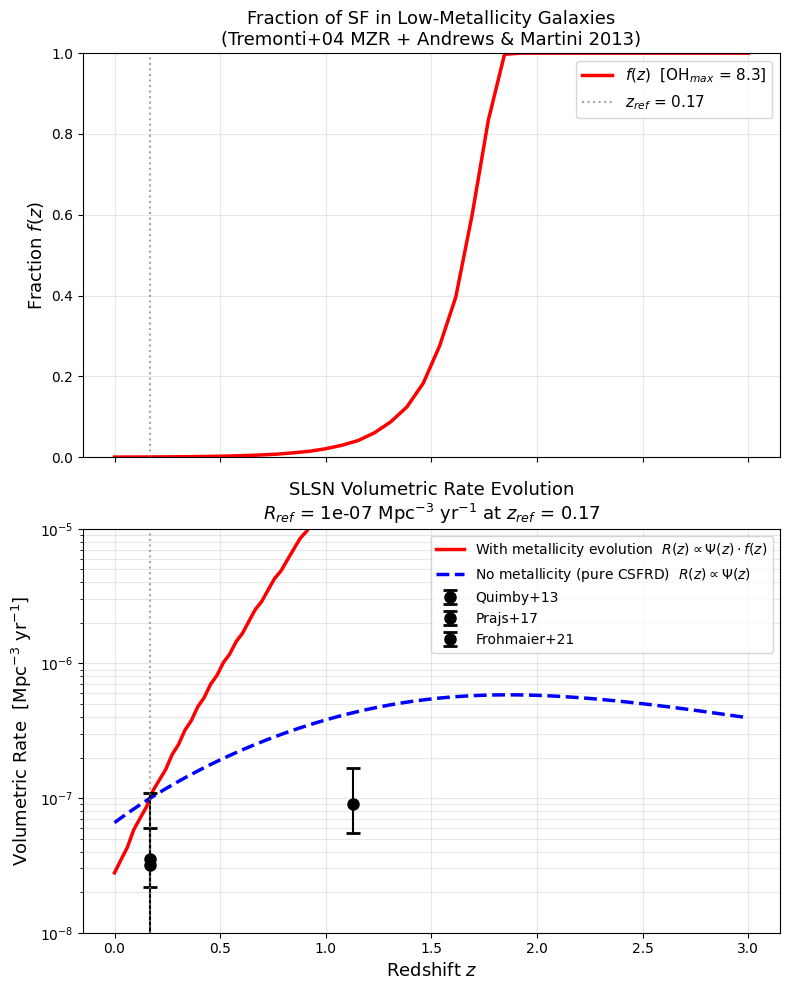

Saved: rate_evolution_comparison_physical.png


In [34]:
# ============================================================================
# CELL 2: Rate evolution comparison — analytical R(z) curves (model-agnostic)
# Shows SFR x metallicity fraction vs pure-SFR curve + observed measurements.
# No population needed — call once for all models.
# ============================================================================
reload(diag_mod)
from slsn_metrics.diagnostics import plot_rate_evolution_comparison

out_rate_fig = get_output_dir('SLSNe') / 'rate_evolution_comparison_physical.png'
plot_rate_evolution_comparison(save_path=out_rate_fig)
print(f'Saved: {out_rate_fig.name}')


In [35]:
# Cell 3 - AUDIT TABLE — summary of figure above
# Rate evolution: observed data points used in Cell A's R(z) comparison
# Analytical curves (SFR x metallicity_fraction) are not stored in this namespace.
# Shown here: the 3 published observed rate measurements plotted against the models.
from slsn_metrics.population import OBSERVED_RATES as _obs2
import pandas as pd
_tbl2 = pd.DataFrame(_obs2)
_tbl2['rate_Gpc3yr'] = (_tbl2['rate'] * 1e9).round(1)
_tbl2['err_low_Gpc3yr'] = (_tbl2['err_low'] * 1e9).round(1)
_tbl2['err_high_Gpc3yr'] = (_tbl2['err_high'] * 1e9).round(1)
print("Observed SLSN-I rate measurements plotted in Cell A (rate_evolution_comparison)")
print(_tbl2[['ref','z','rate_Gpc3yr','err_low_Gpc3yr','err_high_Gpc3yr']].to_string(index=False))

Observed SLSN-I rate measurements plotted in Cell A (rate_evolution_comparison)
         ref    z  rate_Gpc3yr  err_low_Gpc3yr  err_high_Gpc3yr
   Quimby+13 0.17         32.0            26.0             77.0
    Prajs+17 1.13         91.0            36.0             76.0
Frohmaier+21 0.17         35.0            13.0             25.0


In [36]:
# ============================================================================
# CELL 4: Build per-model efficiency data from adaptive results CSV
# No population pkl or .npy loading needed — adaptive CSV has everything.
# Builds pop_data dict compatible with downstream plotting cells.
# ============================================================================

METRIC_MAP = {
    'detect':       'SLSN_Detect_Physical_Metric',
    'characterize': 'SLSN_Characterize_Physical_Metric',
    'villar':       'SLSN_Villar_Physical_Metric',
    'elasticc':     'SLSN_ELAsTiCC_Metric',
    'spectrigger':  'SLSN_SpecTrigger_Physical_Metric',
}
METRIC_KEYS = list(METRIC_MAP.keys())

pop_data = {}

for model in MODELS:
    if model not in ADAPTIVE:
        print(f'Skipping {model} — no adaptive results')
        continue

    df = ADAPTIVE[model]
    print(f'\n{model}:')

    metric_arrays = {m: {} for m in METRIC_KEYS}
    z_bins = sorted(df[['z_lo','z_hi']].drop_duplicates().values.tolist())

    for short, full in METRIC_MAP.items():
        for cadence in CADENCES:
            sub = df[(df['metric']==full) & (df['cadence']==cadence)].copy()
            if sub.empty:
                metric_arrays[short][cadence] = None
                continue
            # Use z_lo+z_hi as lookup keys — one row per z-bin per cadence
            eff_dict = dict(zip(
                zip(sub['z_lo'], sub['z_hi']),
                sub['efficiency']
            ))
            n_dict = dict(zip(
                zip(sub['z_lo'], sub['z_hi']),
                sub['n_events']
            ))
            metric_arrays[short][cadence] = {
                'z_bins':     [(z0,z1) for z0,z1 in z_bins],
                'efficiency': [float(eff_dict.get((z0,z1), np.nan)) for z0,z1 in z_bins],
                'n_events':   [int(n_dict.get((z0,z1), 0))          for z0,z1 in z_bins],
            }

    z_lo_arr  = np.array([b[0] for b in z_bins])
    z_hi_arr  = np.array([b[1] for b in z_bins])
    z_centers = 0.5 * (z_lo_arr + z_hi_arr)

    pop_data[model] = {
        'z_bins':      z_bins,
        'z_lo':        z_lo_arr,
        'z_hi':        z_hi_arr,
        'z_centers':   z_centers,
        'detect':       metric_arrays['detect'],
        'characterize': metric_arrays['characterize'],
        'spectrigger':  metric_arrays['spectrigger'],
        'villar':       metric_arrays['villar'],
        'elasticc':     metric_arrays['elasticc'],
    }
    print(f'  z-bins: {len(z_bins)}, cadences with data: {CADENCES}')

print('\n=== Adaptive efficiency data loaded for all models ===')



naive_physical:
  z-bins: 48, cadences with data: ['baseline_v5.1.1_10yrs', 'baseline_v5.3.0_10yrs']

o_dependent_physical:
  z-bins: 49, cadences with data: ['baseline_v5.1.1_10yrs', 'baseline_v5.3.0_10yrs']

fe_dependent_physical:
  z-bins: 49, cadences with data: ['baseline_v5.1.1_10yrs', 'baseline_v5.3.0_10yrs']

=== Adaptive efficiency data loaded for all models ===


Loading physical templates...
[load_magnitude_grid] Loaded with filters: ['u', 'g', 'r', 'i', 'z', 'y'], shape=(265, 100, 79), convention=apparent ✓
Templates loaded: 265 events

=== Population diagnostics: naive_physical ===
[LOAD] Loaded 2034661 SLSNe from /users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/output/SLSNe/shared/population_naive_physical.pkl
[LOAD] z-filtered to 2034661 events (z_min=0.1, z_max=5.0)


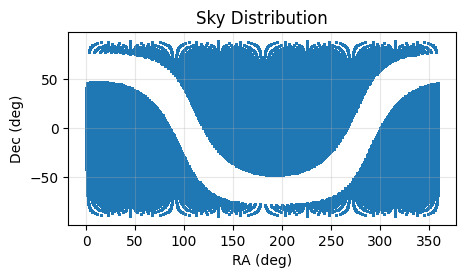

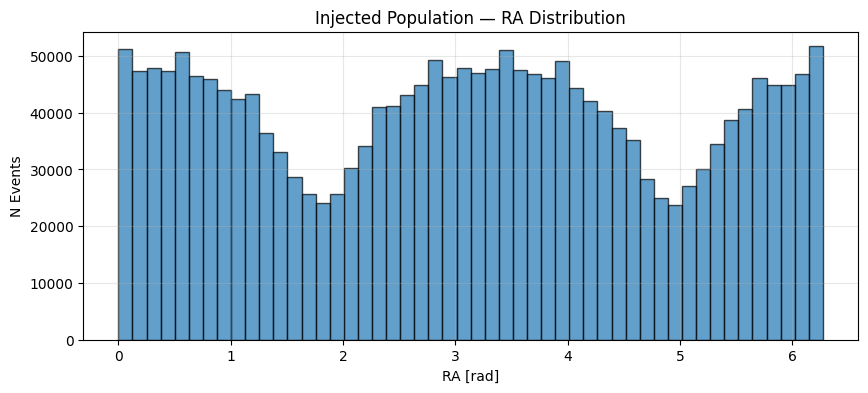

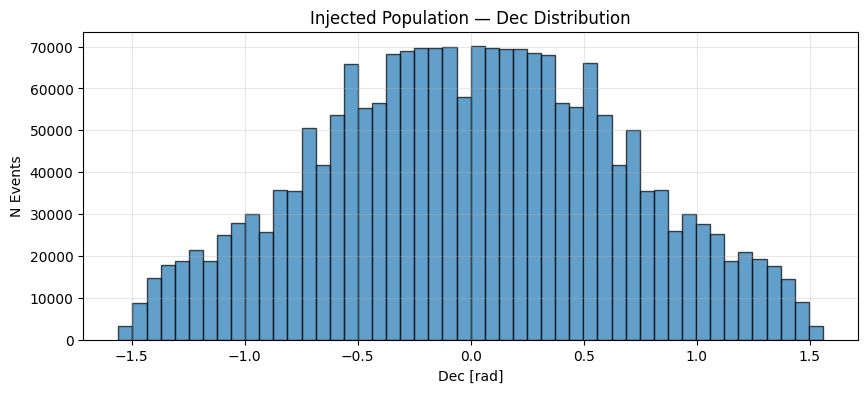

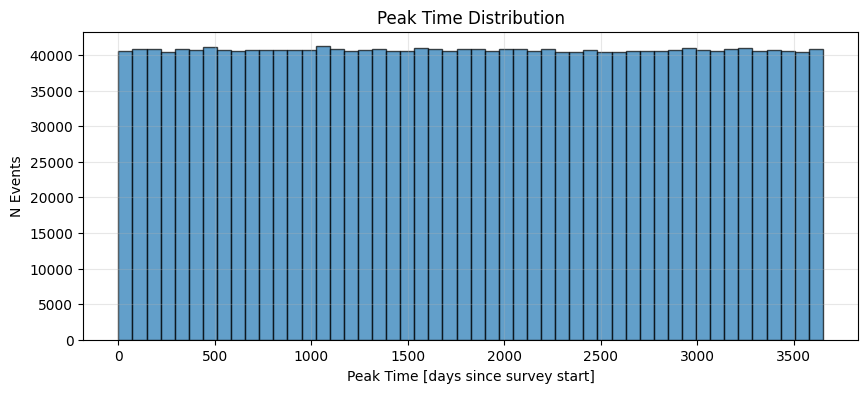

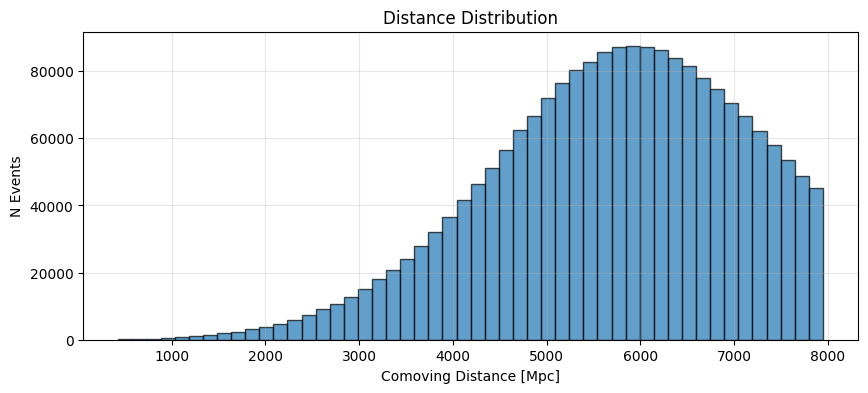

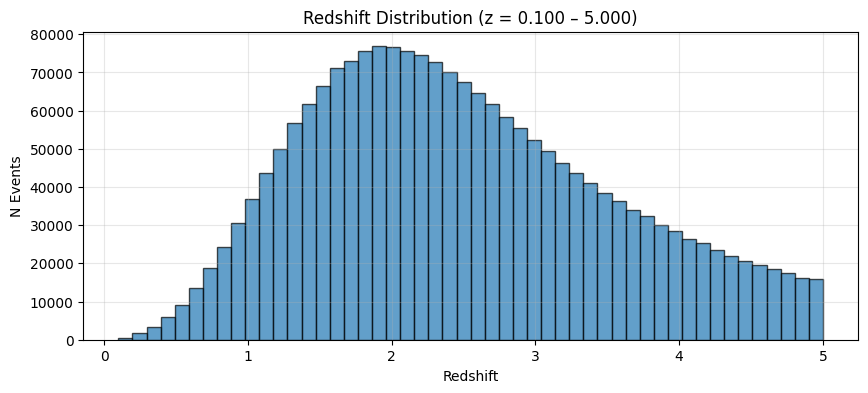

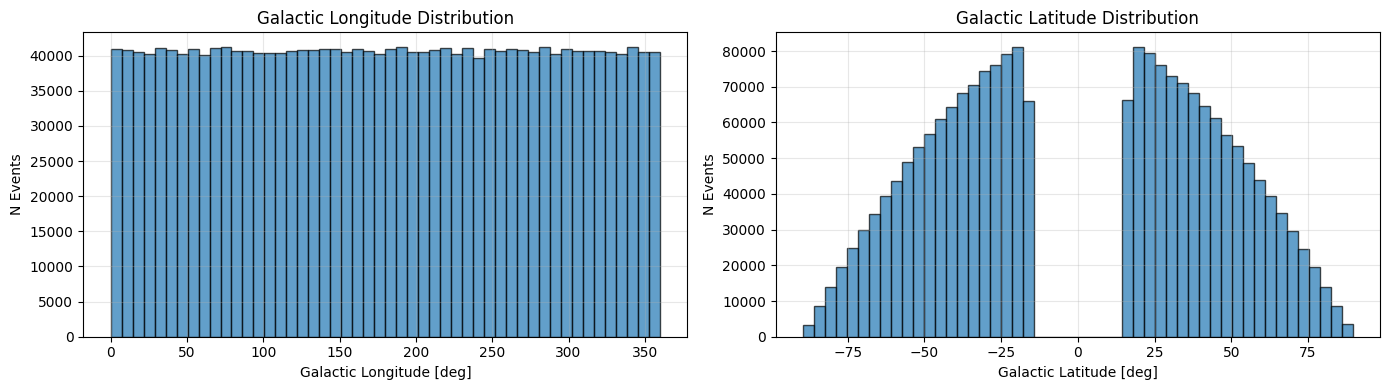

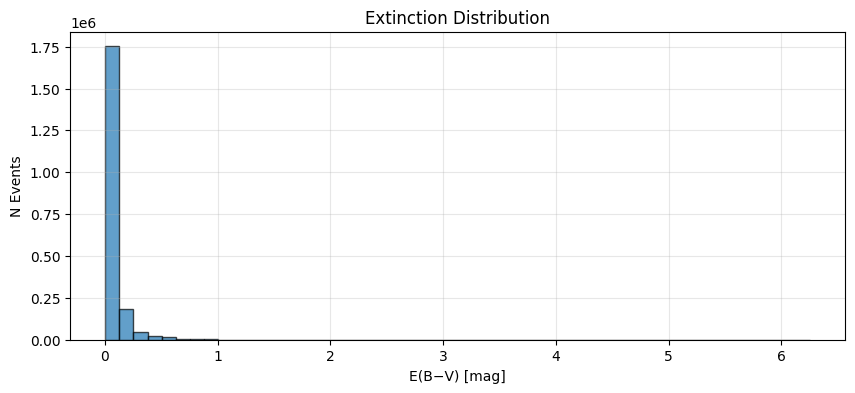

  Diagnostics saved to /users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/output/SLSNe/naive_physical

=== Population diagnostics: o_dependent_physical ===
[LOAD] Loaded 7033255 SLSNe from /users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/output/SLSNe/shared/population_o_dependent_physical.pkl
[LOAD] z-filtered to 7033255 events (z_min=0.1, z_max=5.0)


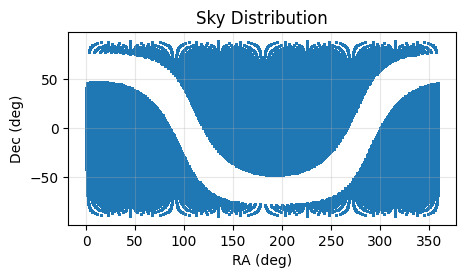

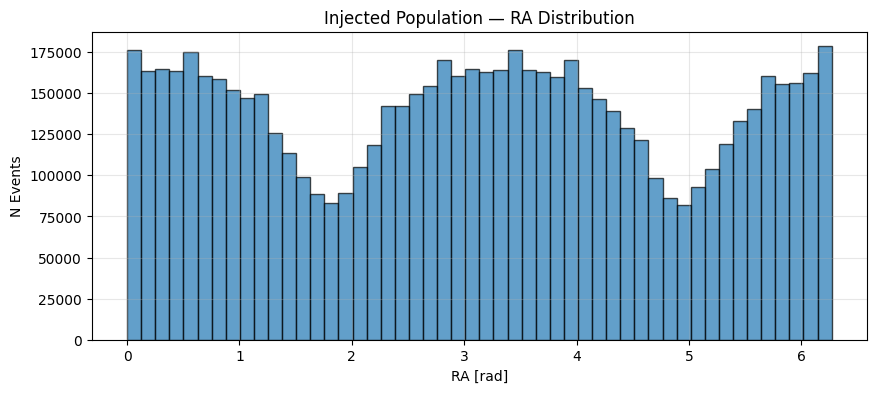

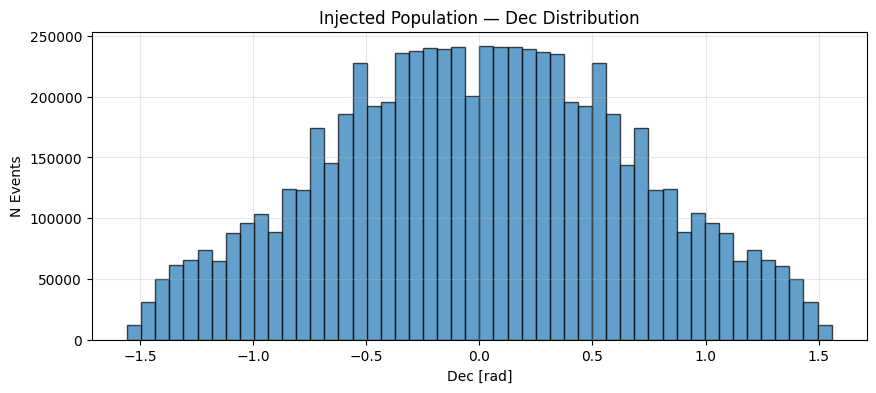

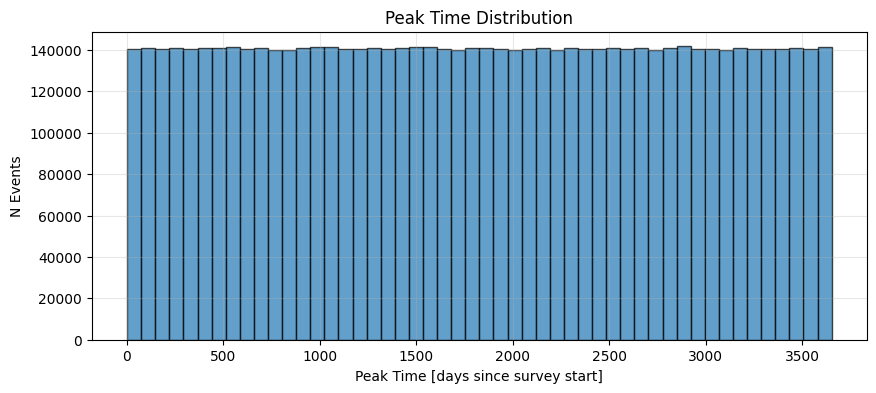

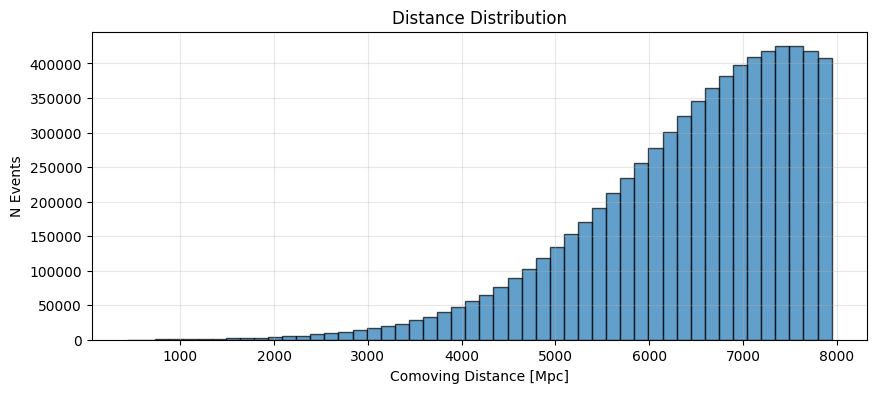

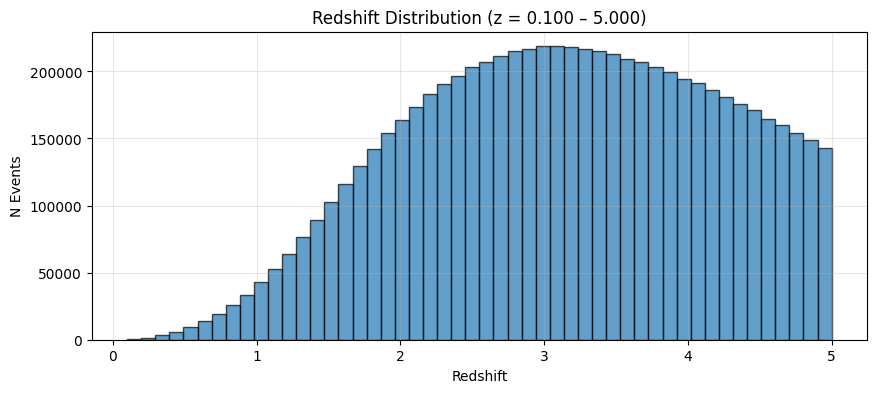

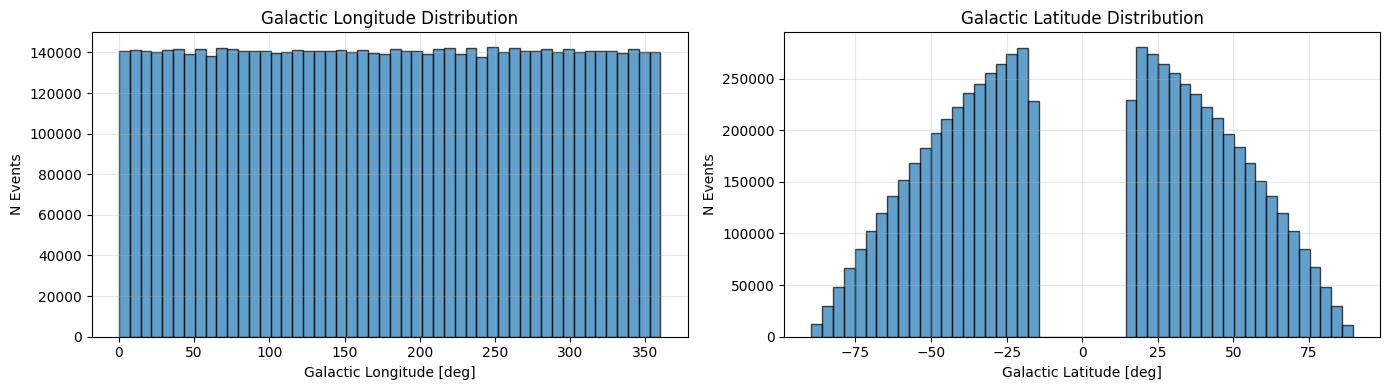

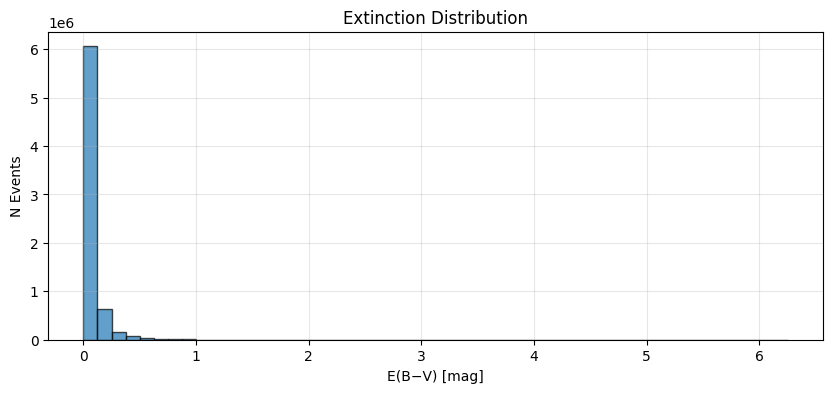

  Diagnostics saved to /users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/output/SLSNe/o_dependent_physical

=== Population diagnostics: fe_dependent_physical ===
[LOAD] Loaded 14432797 SLSNe from /users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/output/SLSNe/shared/population_fe_dependent_physical.pkl
[LOAD] z-filtered to 14432797 events (z_min=0.1, z_max=5.0)


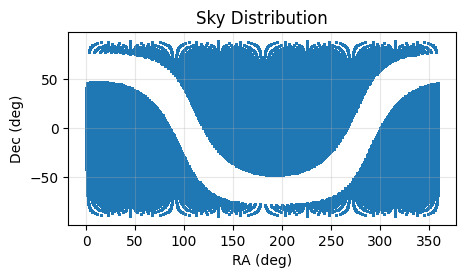

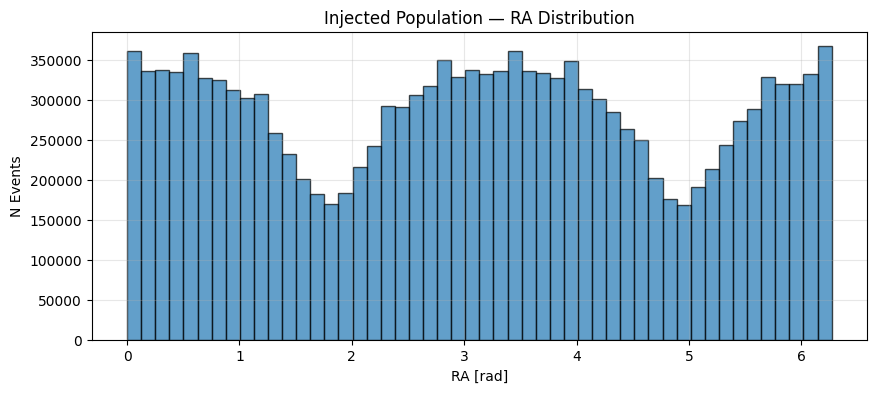

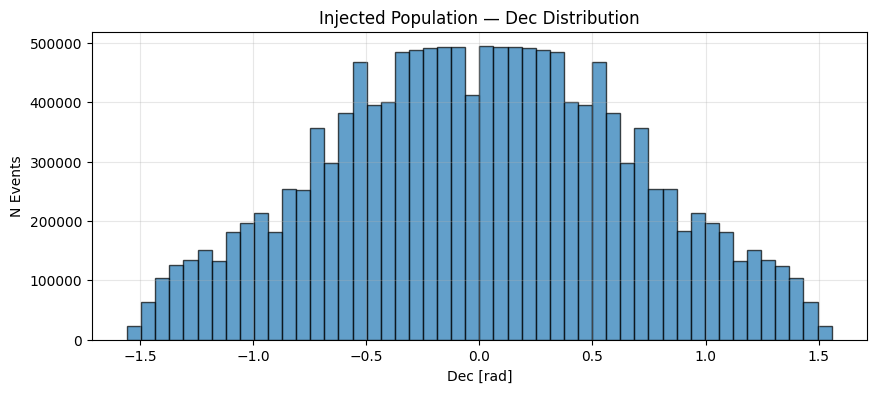

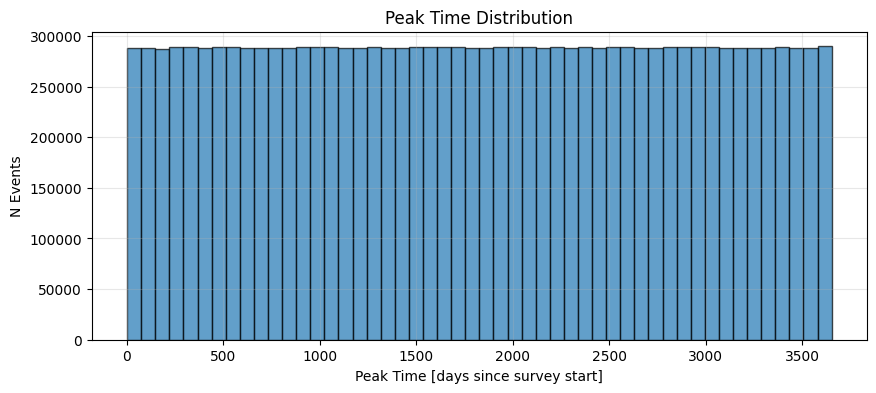

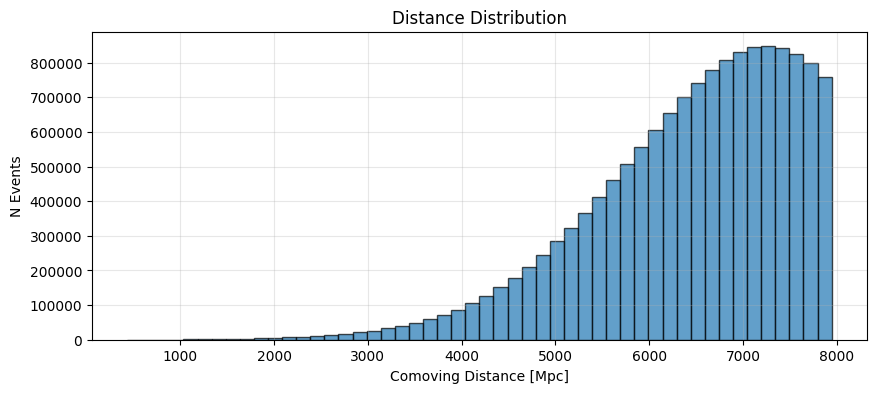

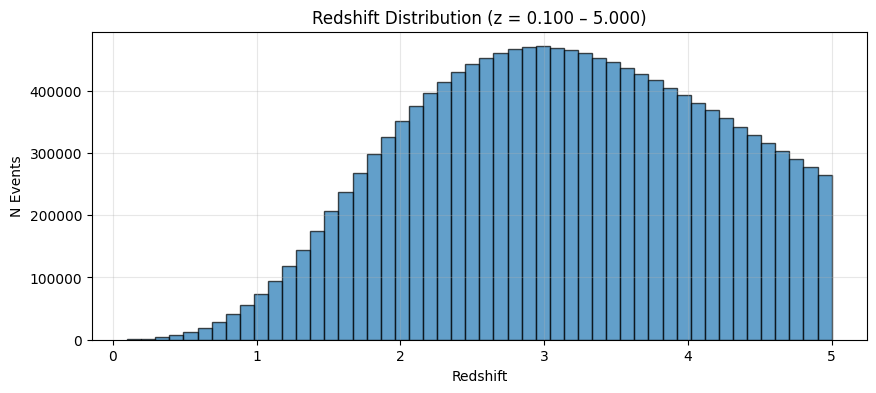

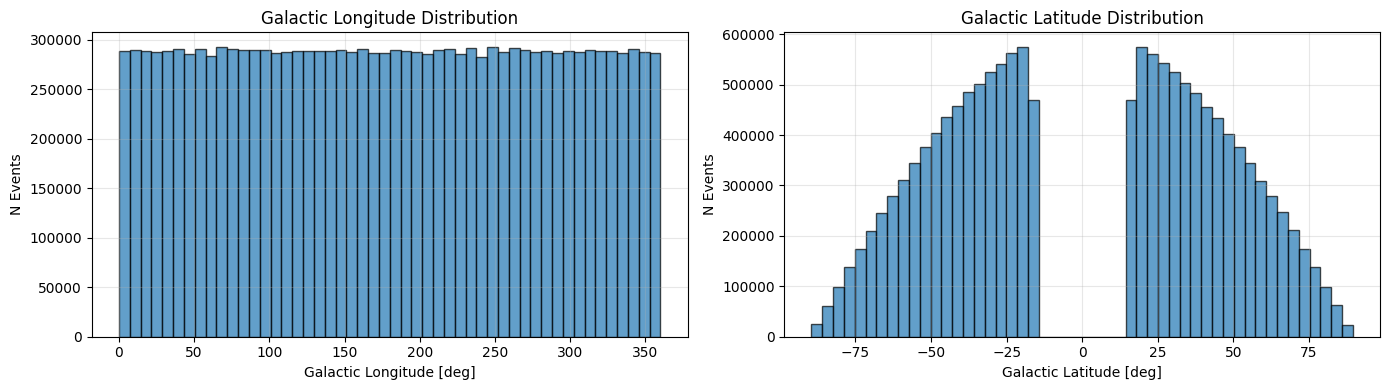

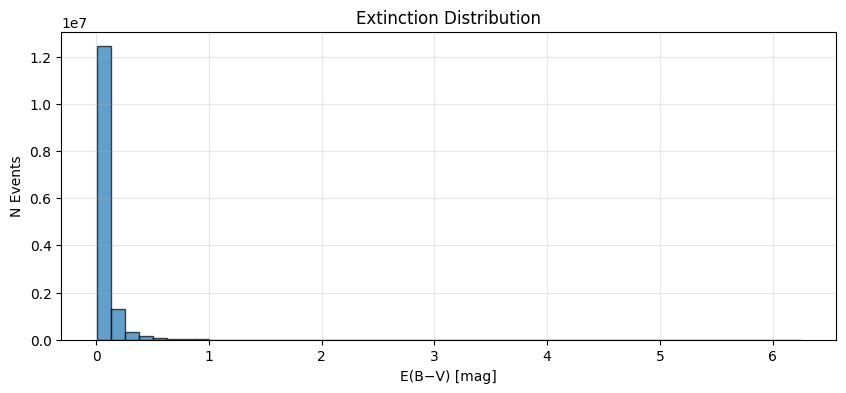

  Diagnostics saved to /users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/output/SLSNe/fe_dependent_physical

=== Population diagnostics complete ===


In [37]:
# ============================================================================
# CELL 5: Population diagnostics — all 3 models
# Loads templates and population slicers for diagnostics.
# Also caches pop_slicers dict for Cells C and D.
# ============================================================================
from slsn_metrics.model import LC
from slsn_metrics.population import generate_SLSN_PopSlicer
reload(diag_mod)
from slsn_metrics.diagnostics import plot_population_diagnostics

# Load templates (needed by generate_SLSN_PopSlicer)
print('Loading physical templates...')
templates = LC(load_from=str(SHARED_DIR / 'physical_templates.pkl'))
templates.load_magnitude_grid(str(SHARED_DIR / 'physical_mag_grid.pkl'))
print(f'Templates loaded: {len(templates.sed_grid)} events')

pop_slicers = {}

for model in MODELS:
    print(f'\n=== Population diagnostics: {model} ===')
    pop_pkl   = SHARED_DIR / f'population_{model}.pkl'
    model_dir = get_output_dir('SLSNe', subdir=model)

    pop = generate_SLSN_PopSlicer(
    lc_model=templates,
    load_from=str(pop_pkl),
    z_min=0.1,        
    z_max=5.0,        
    make_debug_plots=False
    )

    pop_slicers[model] = pop
    sp = pop.slice_points

    plot_population_diagnostics(
        ra_rad        = sp['ra'],
        dec_rad       = sp['dec'],
        peak_times    = sp['peak_time'],
        distances_mpc = sp['distance'],
        z_vals        = sp['z'],
        ebv           = sp.get('ebv', None),
        gall          = sp.get('gall', None),
        galb          = sp.get('galb', None),
        outdir        = str(model_dir),
        prefix        = f'population_{model}'
    )
    print(f'  Diagnostics saved to {model_dir}')

print('\n=== Population diagnostics complete ===')


In [38]:
# ============================================================================
# CELL 7: Build combined DataFrame from adaptive results
# Columns: z_lo, z_hi, cadence, metric, n_events, n_success, efficiency,
#          sigma, model, per_year, cadence_short, model_label
# ============================================================================

cadence_labels = {
    'baseline_v5.1.1_10yrs':    'baseline v5.1.1',
    'baseline_v5.3.0_10yrs':    'baseline v5.3.0',
    'noroll_v5.0.0_10yrs':      'noroll',
    'poor_weather_v5.0.1_10yrs':'poor_weather',
}
model_labels = {
    'fe_dependent_physical': 'Fe-dependent (Physical)',
    'o_dependent_physical':  'O-dependent (Physical)',
    'naive_physical':        'Naive SFR (Physical)',
}

rows = []
for model, df_adap in ADAPTIVE.items():
    df_s = df_adap.copy()
    df_s['model']    = model
    df_s['per_year'] = df_s['n_success'] / SURVEY_YEARS
    rows.append(df_s)

df_all = pd.concat(rows, ignore_index=True)
df_all['cadence_short'] = df_all['cadence'].map(cadence_labels)
df_all['model_label']   = df_all['model'].map(model_labels)

print(f'Loaded {len(df_all)} rows across {df_all["model"].nunique()} models')
print(f'Metrics present: {df_all["metric"].unique().tolist()}')
print(f'Cadences present: {df_all["cadence"].unique().tolist()}')
print(f'Z-bins: {df_all["z_lo"].nunique()} unique bins')
print(f'\nSample rows:')
print(df_all[df_all['metric']=='SLSN_ELAsTiCC_Metric'].head(4).to_string())

Loaded 1460 rows across 3 models
Metrics present: ['SLSN_Detect_Physical_Metric', 'SLSN_Characterize_Physical_Metric', 'SLSN_Villar_Physical_Metric', 'SLSN_ELAsTiCC_Metric', 'SLSN_SpecTrigger_Physical_Metric']
Cadences present: ['baseline_v5.1.1_10yrs', 'baseline_v5.3.0_10yrs']
Z-bins: 49 unique bins

Sample rows:
                  cadence                metric  n_events  n_success  efficiency  z_lo  z_hi     sigma           model  per_year    cadence_short           model_label
3   baseline_v5.1.1_10yrs  SLSN_ELAsTiCC_Metric       564        368    0.652482   0.1   0.2  0.020051  naive_physical      36.8  baseline v5.1.1  Naive SFR (Physical)
8   baseline_v5.3.0_10yrs  SLSN_ELAsTiCC_Metric       564        362    0.641844   0.1   0.2  0.020189  naive_physical      36.2  baseline v5.3.0  Naive SFR (Physical)
13  baseline_v5.1.1_10yrs  SLSN_ELAsTiCC_Metric      1735       1100    0.634006   0.2   0.3  0.011565  naive_physical     110.0  baseline v5.1.1  Naive SFR (Physical)
18  baseline

In [39]:
# ============================================================================
# CELL 8: Summary table — detections/yr and efficiency, all combinations
# Sums n_success across all z-bins per model × cadence × metric
# ============================================================================

METRIC_NAMES = {
    'SLSN_Detect_Physical_Metric':       'Detect',
    'SLSN_Characterize_Physical_Metric': 'Characterize',
    'SLSN_Villar_Physical_Metric':       'Villar',
    'SLSN_ELAsTiCC_Metric':              'ELAsTiCC',
    'SLSN_SpecTrigger_Physical_Metric':  'SpecTrigger',
}

# Aggregate across z-bins: sum n_success, sum n_events per model×cadence×metric
agg = df_all.groupby(['model_label', 'cadence_short', 'metric']).agg(
    n_success=('n_success', 'sum'),
    n_events=('n_events',  'sum'),
).reset_index()
agg['per_year']   = agg['n_success'] / SURVEY_YEARS
agg['efficiency'] = agg['n_success'] / agg['n_events']
agg['metric_short'] = agg['metric'].map(METRIC_NAMES)

CADENCE_ORDER = ['baseline v5.1.1', 'baseline v5.3.0', 'noroll', 'poor_weather']
MODEL_ORDER   = ['Naive SFR (Physical)', 'O-dependent (Physical)', 'Fe-dependent (Physical)']

for metric_full, metric_short in METRIC_NAMES.items():
    sub = agg[agg['metric'] == metric_full]
    if sub.empty:
        print(f'No data for {metric_short}')
        continue

    pivot = sub.pivot_table(
        index='model_label',
        columns='cadence_short',
        values='per_year',
        aggfunc='first'
    ).reindex(index=MODEL_ORDER, columns=CADENCE_ORDER)

    print(f'\n=== {metric_short} — detections per year ===')
    print(pivot.round(1).to_string())

# Overall efficiency summary for Detect
print('\n=== Detect — overall efficiency [%] (all z-bins combined) ===')
det = agg[agg['metric'] == 'SLSN_Detect_Physical_Metric']
pivot_eff = det.pivot_table(
    index='model_label',
    columns='cadence_short',
    values='efficiency',
    aggfunc='first'
).reindex(index=MODEL_ORDER, columns=CADENCE_ORDER) * 100
print(pivot_eff.round(3).to_string())


=== Detect — detections per year ===
cadence_short            baseline v5.1.1  baseline v5.3.0  noroll  poor_weather
model_label                                                                    
Naive SFR (Physical)             16630.9          16549.9     NaN           NaN
O-dependent (Physical)           24471.8          24410.9     NaN           NaN
Fe-dependent (Physical)          46303.4          46260.8     NaN           NaN

=== Characterize — detections per year ===
cadence_short            baseline v5.1.1  baseline v5.3.0  noroll  poor_weather
model_label                                                                    
Naive SFR (Physical)             13516.7          13418.5     NaN           NaN
O-dependent (Physical)           19174.4          19087.5     NaN           NaN
Fe-dependent (Physical)          35678.2          35636.2     NaN           NaN

=== Villar — detections per year ===
cadence_short            baseline v5.1.1  baseline v5.3.0  noroll  poor_weather


In [40]:
# ============================================================================
# CELL 9: Simulated vs observed rates — all 3 models
# Reuses pop_slicers cached by Cell B (no reload needed).
# ============================================================================
reload(diag_mod)
from slsn_metrics.diagnostics import compare_simulated_vs_observed_rates

rate_tables = {}
for model in MODELS:
    print(f'\n{"="*65}')
    print(f'Model: {model_labels[model]}')
    df_rate = compare_simulated_vs_observed_rates(pop_slicers[model])
    rate_tables[model] = df_rate



Model: Naive SFR (Physical)

SIMULATED VS OBSERVED RATE COMPARISON
   z_min    z_max    z_mid  n_events  volume_Mpc3  rate_simulated  rate_observed  ratio_sim/obs reference
1.00e-01 2.50e-01 1.75e-01      1197     3.25e+09        3.68e-08       3.20e-08       1.15e+00 Quimby+13
2.50e-01 4.00e-01 3.25e-01      4594     9.22e+09        4.99e-08            NaN            NaN         —
4.00e-01 7.00e-01 5.50e-01     30536     4.05e+10        7.53e-08            NaN            NaN         —
7.00e-01 1.00e+00 8.50e-01     77788     6.83e+10        1.14e-07            NaN            NaN         —
1.00e+00 1.50e+00 1.25e+00    261386     1.57e+11        1.66e-07       9.10e-08       1.83e+00  Prajs+17
1.50e+00 2.00e+00 1.75e+00    374221     1.86e+11        2.02e-07            NaN            NaN         —


Model: O-dependent (Physical)

SIMULATED VS OBSERVED RATE COMPARISON
   z_min    z_max    z_mid  n_events  volume_Mpc3  rate_simulated  rate_observed  ratio_sim/obs reference
1.00e-01 2.50

SED spot check — apparent mags from synthesize_mag_at_z()
 event     z  filt      mag
--------------------------------
     0   0.3     g   26.206
     0   0.3     r   24.980
     0   0.3     i   24.363
     0   0.3     z   24.054
     0   1.5     g   36.849
     0   1.5     r   33.518
     0   1.5     i   31.389
     0   1.5     z   30.135
     0   3.0     g   46.009
     0   3.0     r   42.243
     0   3.0     i   38.890
     0   3.0     z   36.840
     1   0.3     g   23.860
     1   0.3     r   22.653
     1   0.3     i   22.319
     1   0.3     z   22.183
     1   1.5     g   33.648
     1   1.5     r   30.824
     1   1.5     i   29.015
     1   1.5     z   27.904
     1   3.0     g   42.131
     1   3.0     r   38.237
     1   3.0     i   35.477
     1   3.0     z   33.776
     2   0.3     g   21.802
     2   0.3     r   20.933
     2   0.3     i   20.706
     2   0.3     z   20.631
     2   1.5     g   30.347
     2   1.5     r   28.009
     2   1.5     i   26.561
     2   1.5 

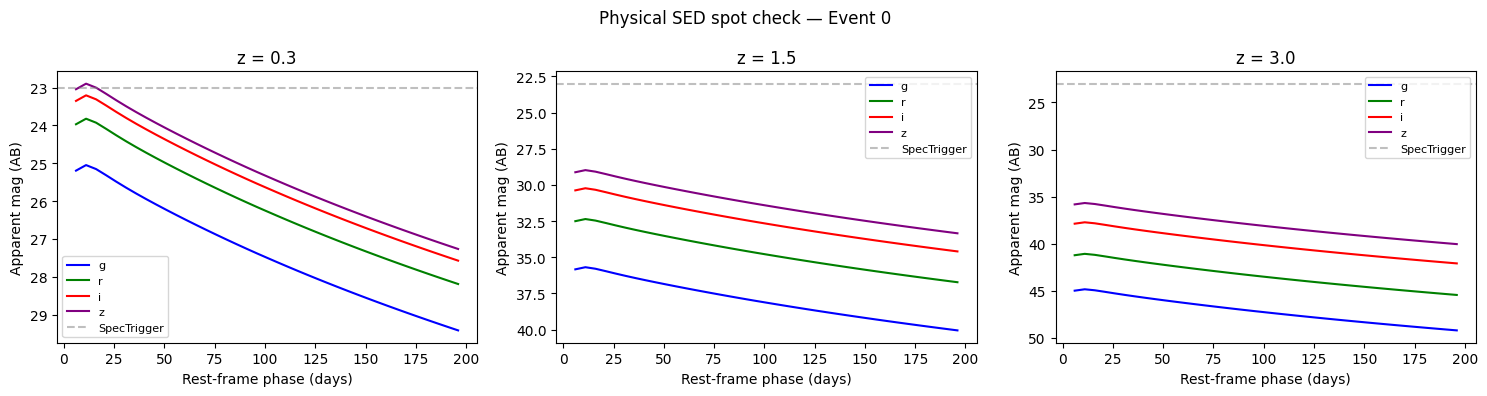

In [41]:
# Cell 10 - SED spot check — physical track only
# Verify synthesize_mag_at_z() produces sensible magnitudes
# at representative redshifts before trusting metric results.
# GP templates do not use this code path.

from slsn_metrics.model import synthesize_mag_at_z

test_redshifts = [0.3, 1.5, 3.0]
test_phase     = 50.0   # mid-range post-peak phase
test_filters   = ['g', 'r', 'i', 'z']
n_events_check = 5

print('SED spot check — apparent mags from synthesize_mag_at_z()')
print(f'{"event":>6} {"z":>5} {"filt":>5} {"mag":>8}')
print('-' * 32)
for ev_idx in range(n_events_check):
    sed_entry = templates.sed_grid[ev_idx]
    for z_test in test_redshifts:
        for filt in test_filters:
            m = synthesize_mag_at_z(sed_entry, test_phase, z_test, filt)
            status = f'{m:.3f}' if np.isfinite(m) else 'NaN'
            print(f'{ev_idx:>6} {z_test:>5.1f} {filt:>5} {status:>8}')

# Light curve plot at three redshifts for event 0
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
phases_plot = np.arange(1, 200, 5).astype(float)
filt_colors = {'g': 'blue', 'r': 'green', 'i': 'red', 'z': 'purple'}
for ax, z_test in zip(axes, test_redshifts):
    sed_entry = templates.sed_grid[0]
    for filt, col in filt_colors.items():
        mags_plot = np.array([synthesize_mag_at_z(sed_entry, ph, z_test, filt)
                              for ph in phases_plot])
        finite = np.isfinite(mags_plot)
        if finite.sum() > 0:
            ax.plot(phases_plot[finite], mags_plot[finite], color=col, label=filt)
    ax.invert_yaxis()
    ax.set_xlabel('Rest-frame phase (days)')
    ax.set_ylabel('Apparent mag (AB)')
    ax.set_title(f'z = {z_test}')
    ax.axhline(23.0, ls='--', color='gray', alpha=0.5, label='SpecTrigger')
    ax.legend(fontsize=8)
plt.suptitle('Physical SED spot check — Event 0')
plt.tight_layout()
plt.savefig(get_output_dir('SLSNe', subdir='physical_figures') / 'sed_spot_check.png', dpi=150)
plt.show()


In [42]:
# Cell 11 - AUDIT TABLE — summary of figure above
# SED spot check: apparent magnitudes at phase=50d for events 0-4
# Same synthesize_mag_at_z calls as printed above; presented as a pivot table.
import pandas as pd
_rows8 = []
for _ev8 in range(n_events_check):
    _sed8 = templates.sed_grid[_ev8]
    for _z8 in test_redshifts:
        for _f8 in test_filters:
            _m8 = synthesize_mag_at_z(_sed8, test_phase, _z8, _f8)
            _rows8.append({'event': _ev8, 'z': _z8, 'filter': _f8,
                           'mag': round(float(_m8), 3) if np.isfinite(_m8) else float('nan')})
_tbl8 = pd.DataFrame(_rows8)
_tbl8_wide = _tbl8.pivot_table(index=['event', 'z'], columns='filter', values='mag')
print(f"SED spot check — apparent mag at phase={test_phase:.0f}d  (events 0-{n_events_check-1})")
print(_tbl8_wide.to_string())

SED spot check — apparent mag at phase=50d  (events 0-4)
filter          g       i       r       z
event z                                  
0     0.3  26.206  24.363  24.980  24.054
      1.5  36.849  31.389  33.518  30.135
      3.0  46.009  38.890  42.243  36.840
1     0.3  23.860  22.319  22.653  22.183
      1.5  33.648  29.015  30.824  27.904
      3.0  42.131  35.477  38.237  33.776
2     0.3  21.802  20.706  20.933  20.631
      1.5  30.347  26.561  28.009  25.689
      3.0  37.868  32.024  34.330  30.621
3     0.3  21.062  20.429  20.581  20.398
      1.5  29.231  25.499  26.940  24.700
      3.0  36.510  30.890  33.111  29.527
4     0.3  23.591  21.463  21.931  21.363
      1.5  33.544  28.835  30.692  27.677
      3.0  41.975  35.378  38.124  33.671


Saved: physical_eff_vs_z_naive_physical.png


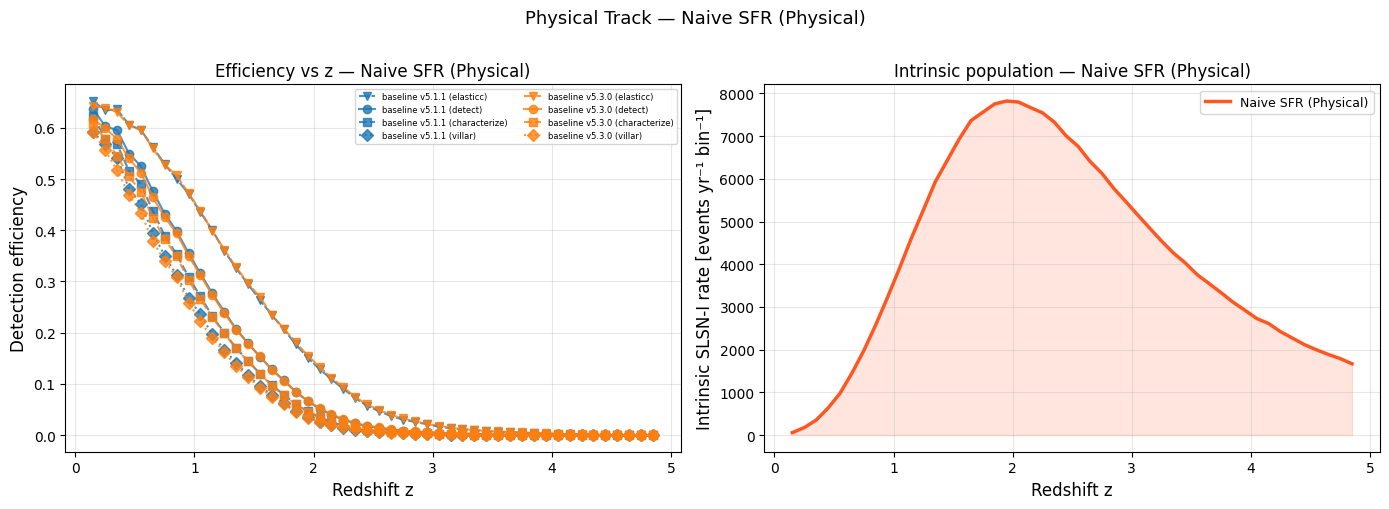

Saved: physical_eff_vs_z_o_dependent_physical.png


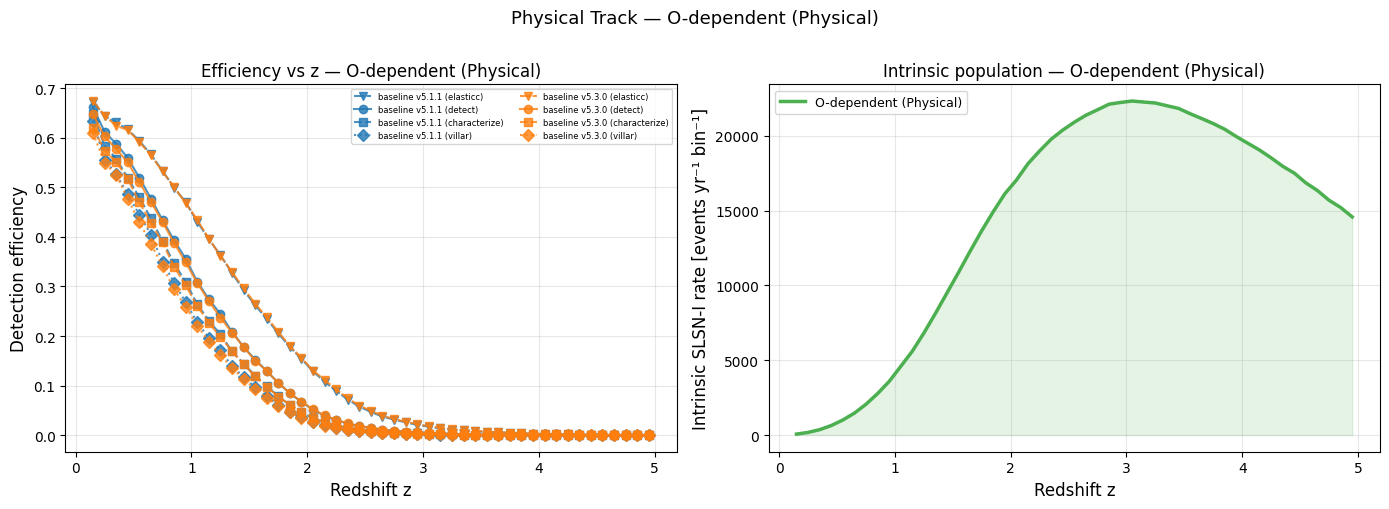

Saved: physical_eff_vs_z_fe_dependent_physical.png


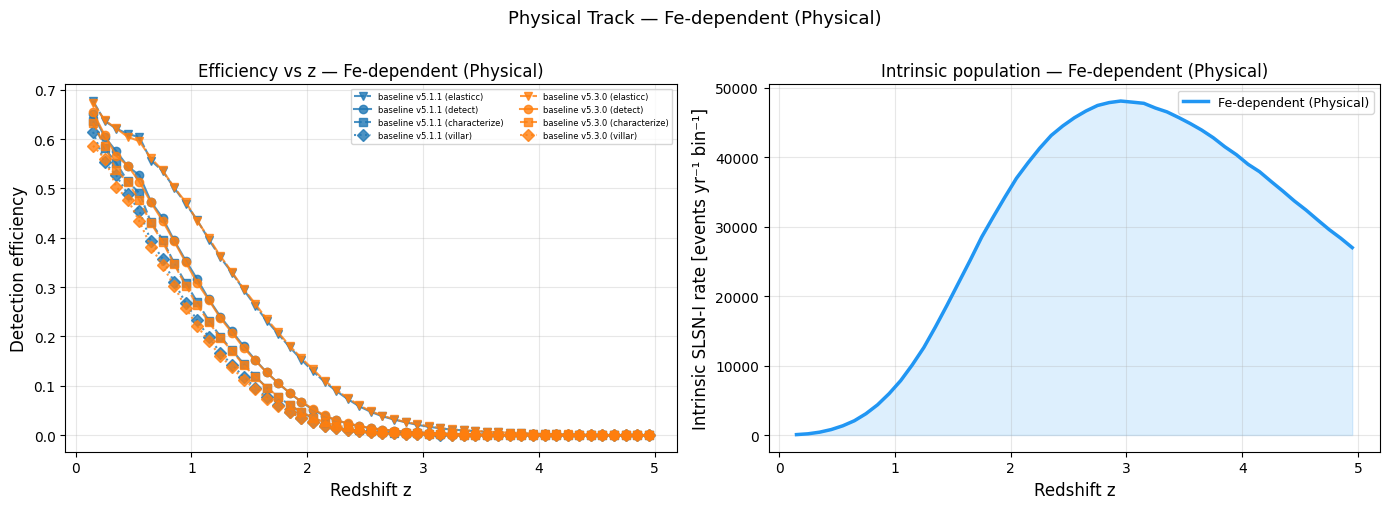

In [43]:
# ============================================================================
# CELL 12: Efficiency vs redshift — per model, all cadences, all metrics
# Left:  Detection efficiency per metric per cadence
# Right: Intrinsic population per model (one line, no metric breakdown)
# ============================================================================

model_labels = {
    'fe_dependent_physical': 'Fe-dependent (Physical)',
    'o_dependent_physical':  'O-dependent (Physical)',
    'naive_physical':        'Naive SFR (Physical)',
}
colors_model = {
    'naive_physical':        '#FF5722',
    'o_dependent_physical':  '#4CAF50',
    'fe_dependent_physical': '#2196F3',
}
colors_cadence = {
    'baseline_v5.1.1_10yrs':    '#1f77b4',
    'baseline_v5.3.0_10yrs':    '#ff7f0e',
    'noroll_v5.0.0_10yrs':      '#2ca02c',
    'poor_weather_v5.0.1_10yrs':'#d62728',
}
cadence_short = {
    'baseline_v5.1.1_10yrs':    'baseline v5.1.1',
    'baseline_v5.3.0_10yrs':    'baseline v5.3.0',
    'noroll_v5.0.0_10yrs':      'noroll',
    'poor_weather_v5.0.1_10yrs':'poor weather',
}
metric_keys_z = ['elasticc', 'detect', 'characterize', 'villar']
ls_metric = {
    'detect':       '-',
    'characterize': '--',
    'villar':       ':',
    'elasticc':     (0, (5, 1)),
}
markers_metric = {
    'detect':       'o',
    'characterize': 's',
    'villar':       'D',
    'elasticc':     'v',
}

for model in MODELS:
    if model not in pop_data:
        continue

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    z_centers = pop_data[model]['z_centers']
    color     = colors_model[model]

    # Left panel — efficiency per metric per cadence
    # Left panel — efficiency per metric per cadence
    # Toggles — edit these to select which cadences and metrics appear
    PLOT_CADENCES_7 = ['baseline_v5.1.1_10yrs', 'baseline_v5.3.0_10yrs'] # or e.g. ['noroll_v5.0.0_10yrs']
    PLOT_METRICS_7  = metric_keys_z                     # or e.g. ['detect', 'elasticc']

    for cadence in PLOT_CADENCES_7:
        for metric in PLOT_METRICS_7:
            entry = pop_data[model][metric].get(cadence)
            if entry is None:
                continue
            eff_bins = entry['efficiency']
            label = f'{cadence_short[cadence]} ({metric})'
            axes[0].plot(z_centers, eff_bins,
                         marker=markers_metric[metric],
                         color=colors_cadence[cadence],
                         ls=ls_metric[metric], lw=1.5,
                         label=label, alpha=0.8)

    # Right panel — intrinsic population only (use ELAsTiCC n_events)
    # All cadences give same n_events per bin — just use first cadence
    ref_cadence = CADENCES[0]
    entry = pop_data[model]['elasticc'].get(ref_cadence)
    if entry is not None:
        n_ev_bins  = entry['n_events']
        count_bins = [n / SURVEY_YEARS for n in n_ev_bins]
        axes[1].plot(z_centers, count_bins,
                     color=color, lw=2.5,
                     label=model_labels[model])
        axes[1].fill_between(z_centers, 0, count_bins,
                             color=color, alpha=0.15)

    for ax in axes:
        ax.set_xlabel('Redshift z', fontsize=12)
        ax.grid(alpha=0.3)

    axes[0].set_ylabel('Detection efficiency', fontsize=12)
    axes[0].set_title(f'Efficiency vs z — {model_labels[model]}', fontsize=12)
    axes[0].legend(fontsize=6, ncol=2)

    axes[1].set_ylabel('Intrinsic SLSN-I rate [events yr⁻¹ bin⁻¹]', fontsize=12)
    axes[1].set_title(f'Intrinsic population — {model_labels[model]}', fontsize=12)
    axes[1].legend(fontsize=9)

    plt.suptitle(f'Physical Track — {model_labels[model]}', fontsize=13, y=1.01)
    plt.tight_layout()
    out_fig = get_output_dir('SLSNe') / f'physical_eff_vs_z_{model}.png'
    plt.savefig(out_fig, dpi=150, bbox_inches='tight')
    print(f'Saved: {out_fig.name}')
    plt.show()

In [44]:
# Cell 13 - AUDIT TABLE — summary of figure above
# Detect efficiency per z-bin — baseline_v5.1.1, detect metric (representative slice)
# Full pop_data available for all 4 cadences × 4 metrics × 3 models.
import pandas as pd
_rows9, _ref9 = [], 'baseline_v5.1.1_10yrs'
for _mdl9 in MODELS:
    if _mdl9 not in pop_data:
        continue
    _ent9 = pop_data[_mdl9]['detect'].get(_ref9)
    if _ent9 is None:
        continue
    for _z9, _e9, _n9 in zip(pop_data[_mdl9]['z_centers'],
                              _ent9['efficiency'], _ent9['n_events']):
        _rows9.append({'model': _mdl9.replace('_physical',''), 'z_center': round(_z9, 2),
                       'n_events': int(_n9), 'efficiency': round(_e9, 4)})
_tbl9 = pd.DataFrame(_rows9)
print(f"Detect efficiency vs z — cadence={_ref9}")
print(_tbl9[_tbl9['efficiency'] > 0].to_string(index=False))

Detect efficiency vs z — cadence=baseline_v5.1.1_10yrs
       model  z_center  n_events  efficiency
       naive      0.15       564      0.6365
       naive      0.25      1735      0.6035
       naive      0.35      3492      0.5954
       naive      0.45      6309      0.5498
       naive      0.55      9755      0.5252
       naive      0.65     14472      0.4762
       naive      0.75     19744      0.4322
       naive      0.85     25776      0.3984
       naive      0.95     32268      0.3556
       naive      1.05     39058      0.3156
       naive      1.15     46121      0.2766
       naive      1.25     52667      0.2413
       naive      1.35     59270      0.2070
       naive      1.45     64270      0.1792
       naive      1.55     69241      0.1528
       naive      1.65     73624      0.1283
       naive      1.75     75591      0.1069
       naive      1.85     77551      0.0848
       naive      1.95     78214      0.0660
       naive      2.05     77970      0.0514


Saved: n_success_per_year_detect_baseline_v5.3.0_10yrs.png


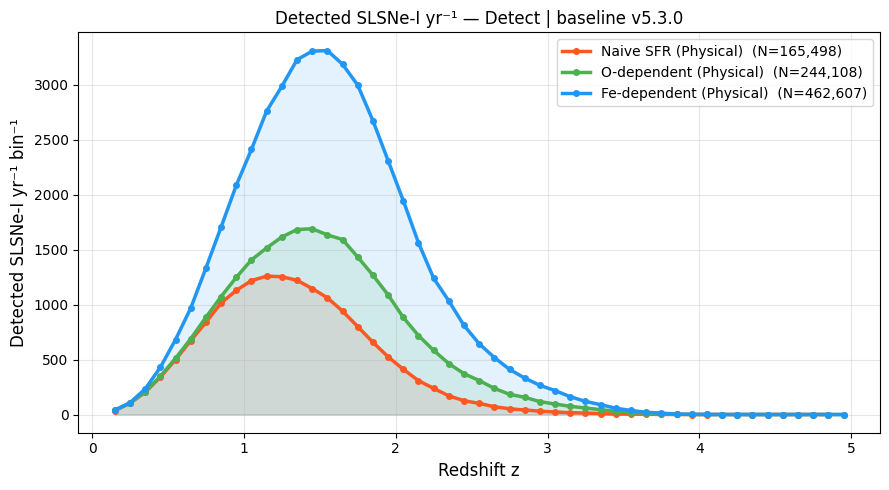

In [45]:
# ============================================================================
# CELL 14: Detected SLSNe-I per year per z-bin — all 3 models, one metric
# ============================================================================
# Reload flags:
#   Templates  : NO
#   Population : NO
#   Mag grid   : NO
#   Kernel     : NO
#
# Toggles — change these to switch metric or cadence:
PLOT_METRIC  = 'detect'                # 'elasticc','detect','characterize','villar'
PLOT_CADENCE = 'baseline_v5.3.0_10yrs'  # any cadence in CADENCES

metric_label_7b = {
    'elasticc':     'ELAsTiCC',
    'detect':       'Detect',
    'characterize': 'Characterize',
    'villar':       'Villar',
}[PLOT_METRIC]

fig, ax = plt.subplots(figsize=(9, 5))

for model in MODELS:
    if model not in pop_data:
        continue
    entry = pop_data[model][PLOT_METRIC].get(PLOT_CADENCE)
    if entry is None:
        print(f'[skip] {model} / {PLOT_CADENCE} not in pop_data')
        continue

    z_centers   = pop_data[model]['z_centers']
    efficiency  = np.array(entry['efficiency'])
    n_events    = np.array(entry['n_events'])
    n_success   = efficiency * n_events
    n_per_year  = n_success / SURVEY_YEARS

    total = n_success.sum()
    label = f'{model_labels[model]}  (N={int(total):,})'

    ax.plot(z_centers, n_per_year,
            color=colors_model[model],
            lw=2.5, marker='o', ms=4,
            label=label)
    ax.fill_between(z_centers, 0, n_per_year,
                    color=colors_model[model], alpha=0.12)

ax.set_xlabel('Redshift z', fontsize=12)
ax.set_ylabel('Detected SLSNe-I yr⁻¹ bin⁻¹', fontsize=12)
ax.set_title(
    f'Detected SLSNe-I yr⁻¹ — {metric_label_7b} | '
    f'{cadence_short[PLOT_CADENCE]}',
    fontsize=12
)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()

out_fig = get_output_dir('SLSNe') / f'n_success_per_year_{PLOT_METRIC}_{PLOT_CADENCE}.png'
plt.savefig(out_fig, dpi=150, bbox_inches='tight')
print(f'Saved: {out_fig.name}')
plt.show()

In [46]:
# Cell 15 - AUDIT TABLE — summary of figure above
# Detected SLSNe-I yr⁻¹ per z-bin — all 3 models at PLOT_METRIC/PLOT_CADENCE
# Matches the plotted curves; zero-efficiency bins omitted.
import pandas as pd
_rows10 = []
for _mdl10 in MODELS:
    if _mdl10 not in pop_data:
        continue
    _ent10 = pop_data[_mdl10][PLOT_METRIC].get(PLOT_CADENCE)
    if _ent10 is None:
        continue
    _zc10 = pop_data[_mdl10]['z_centers']
    _ef10 = np.array(_ent10['efficiency'])
    _ne10 = np.array(_ent10['n_events'])
    _ny10 = _ef10 * _ne10 / SURVEY_YEARS
    for _z, _e, _n, _p in zip(_zc10, _ef10, _ne10.astype(int), _ny10):
        _rows10.append({'model': _mdl10.replace('_physical',''), 'z_center': round(_z, 2),
                        'n_events': _n, 'efficiency': round(_e, 4), 'n_per_yr': round(_p, 2)})
_tbl10 = pd.DataFrame(_rows10)
print(f"Detected SLSNe-I yr⁻¹ per z-bin — metric={PLOT_METRIC} | cadence={cadence_short.get(PLOT_CADENCE, PLOT_CADENCE)}")
print(_tbl10[_tbl10['n_per_yr'] > 0].to_string(index=False))

Detected SLSNe-I yr⁻¹ per z-bin — metric=detect | cadence=baseline v5.3.0
       model  z_center  n_events  efficiency  n_per_yr
       naive      0.15       564      0.6170      34.8
       naive      0.25      1735      0.5994     104.0
       naive      0.35      3492      0.5785     202.0
       naive      0.45      6309      0.5403     340.9
       naive      0.55      9755      0.5123     499.7
       naive      0.65     14472      0.4648     672.6
       naive      0.75     19744      0.4252     839.5
       naive      0.85     25776      0.3942    1016.0
       naive      0.95     32268      0.3501    1129.7
       naive      1.05     39058      0.3120    1218.8
       naive      1.15     46121      0.2731    1259.5
       naive      1.25     52667      0.2382    1254.4
       naive      1.35     59270      0.2061    1221.8
       naive      1.45     64270      0.1784    1146.4
       naive      1.55     69241      0.1535    1062.9
       naive      1.65     73624      0.1278  


naive_physical: 395,117 events at z=3.0-4.0

--- naive_physical x baseline_v5.1.1_10yrs ---
  detect: 627 detected pixels / 36416 injected pixels (1.7%)
  characterize: 279 detected pixels / 36416 injected pixels (0.8%)
  villar: 170 detected pixels / 36416 injected pixels (0.5%)


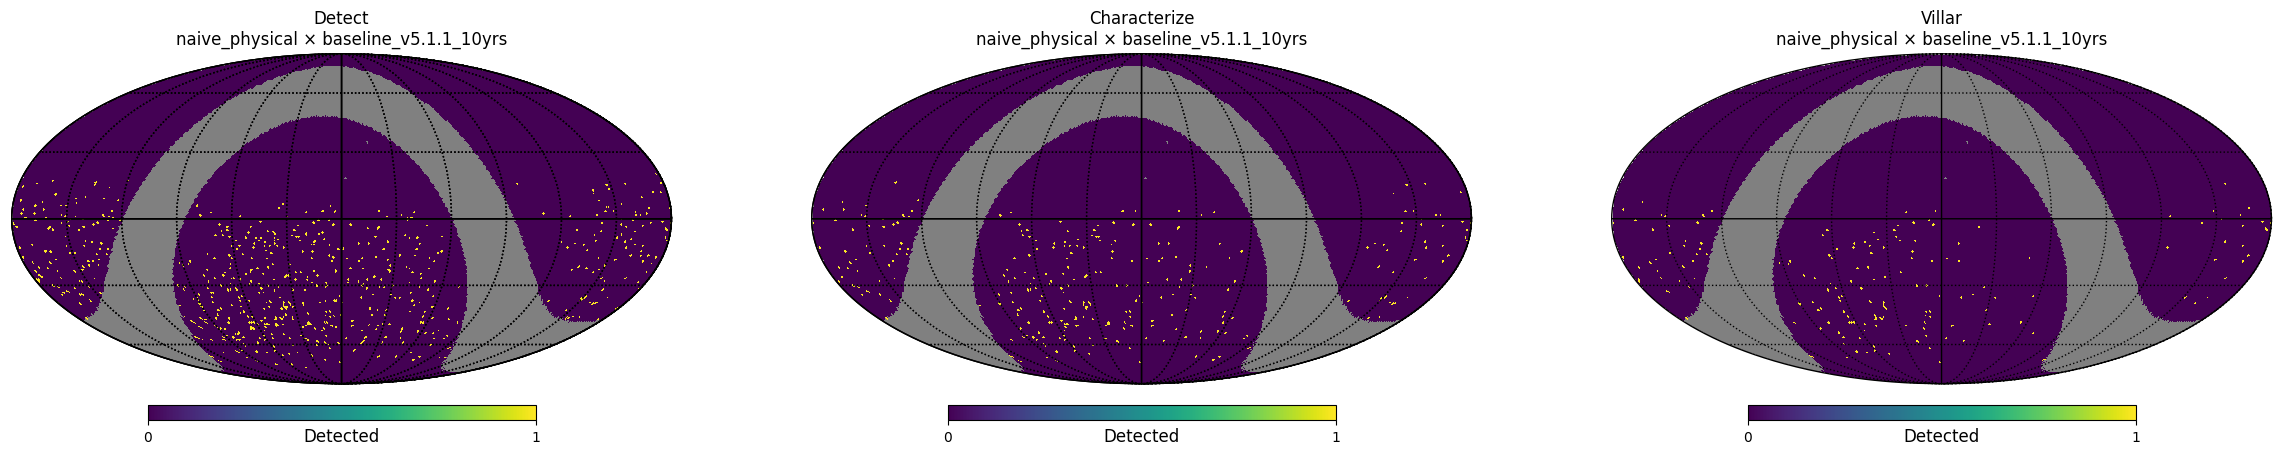

  Saved row: healpix_row_naive_physical_baseline_v5.1.1_10yrs_physical.png

--- naive_physical x baseline_v5.3.0_10yrs ---
  detect: 720 detected pixels / 36416 injected pixels (2.0%)
  characterize: 367 detected pixels / 36416 injected pixels (1.0%)
  villar: 239 detected pixels / 36416 injected pixels (0.7%)


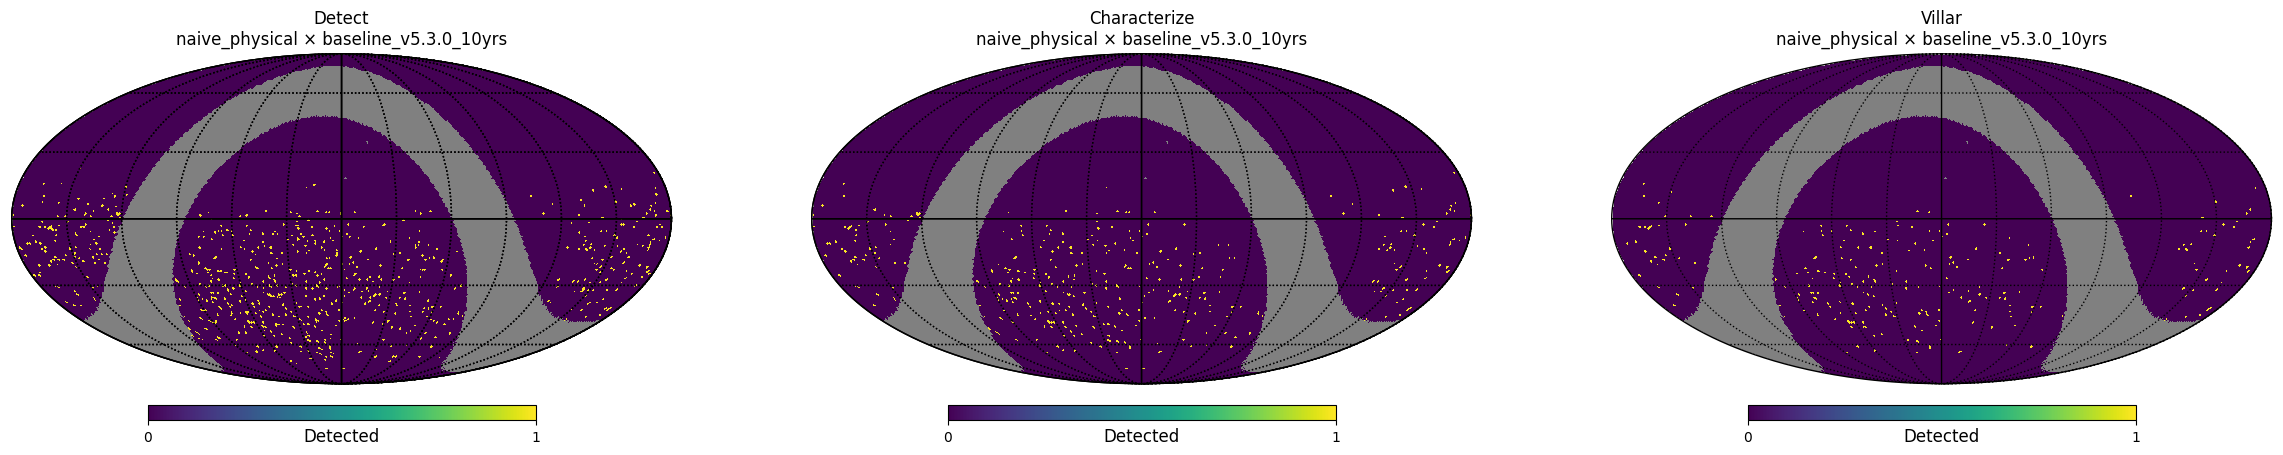

  Saved row: healpix_row_naive_physical_baseline_v5.3.0_10yrs_physical.png

o_dependent_physical: 2,145,478 events at z=3.0-4.0

--- o_dependent_physical x baseline_v5.1.1_10yrs ---
  detect: 2910 detected pixels / 36418 injected pixels (8.0%)
  characterize: 1291 detected pixels / 36418 injected pixels (3.5%)
  villar: 846 detected pixels / 36418 injected pixels (2.3%)


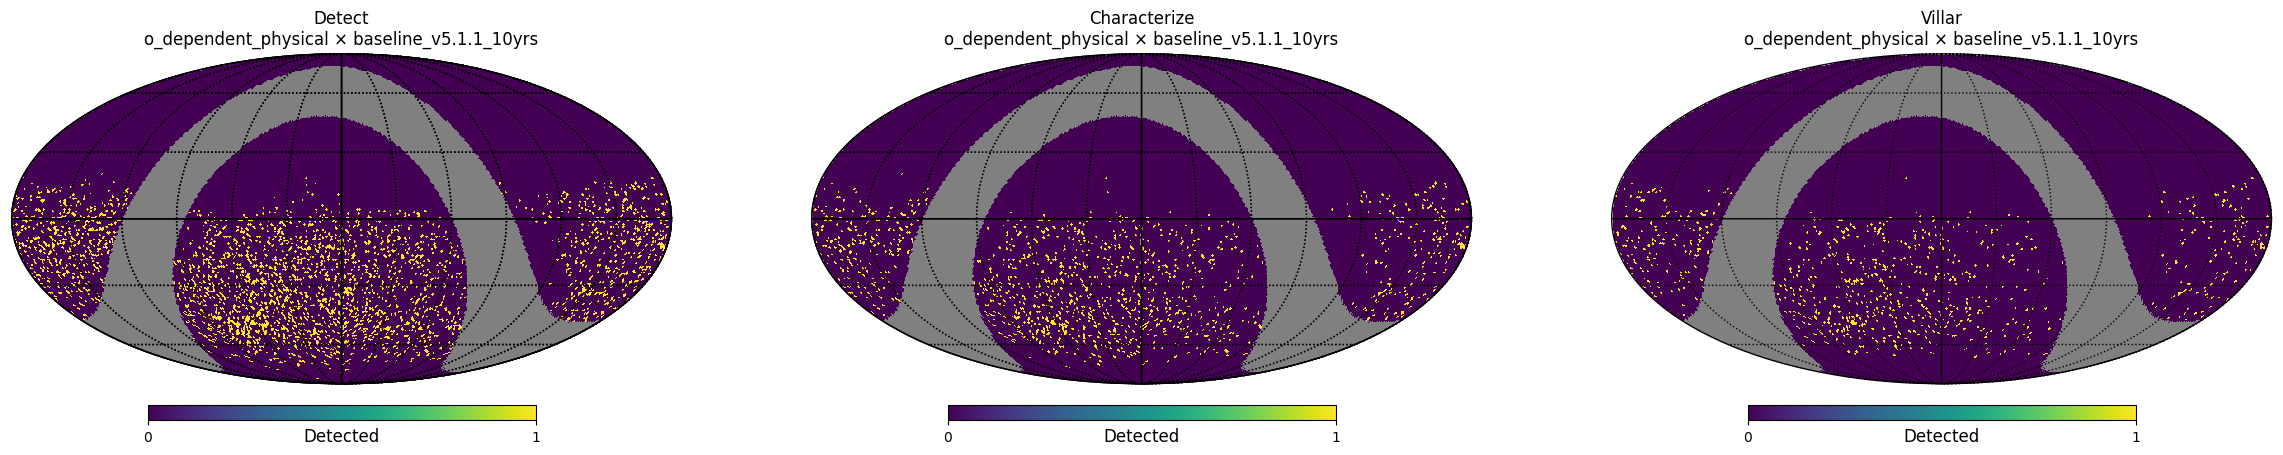

  Saved row: healpix_row_o_dependent_physical_baseline_v5.1.1_10yrs_physical.png

--- o_dependent_physical x baseline_v5.3.0_10yrs ---
  detect: 3104 detected pixels / 36418 injected pixels (8.5%)
  characterize: 1462 detected pixels / 36418 injected pixels (4.0%)
  villar: 942 detected pixels / 36418 injected pixels (2.6%)


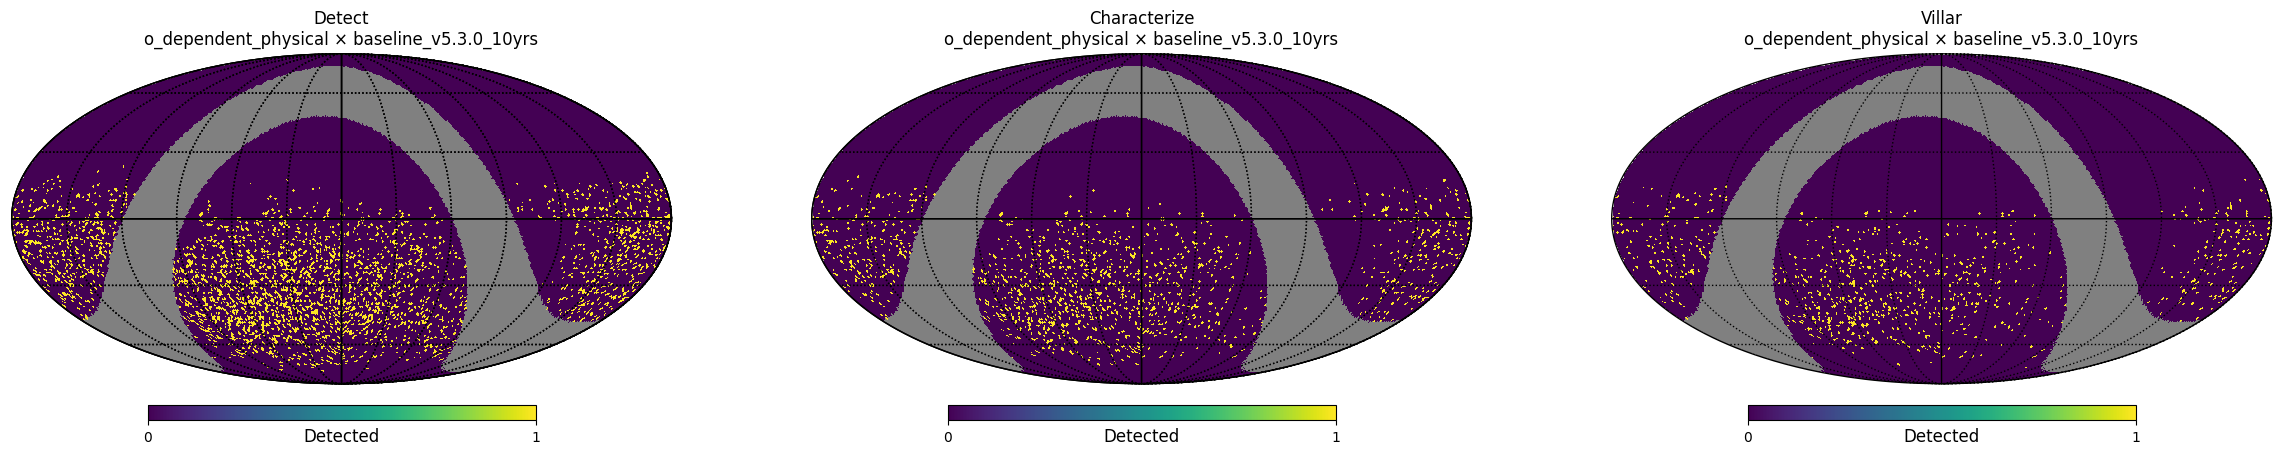

  Saved row: healpix_row_o_dependent_physical_baseline_v5.3.0_10yrs_physical.png

fe_dependent_physical: 4,481,881 events at z=3.0-4.0

--- fe_dependent_physical x baseline_v5.1.1_10yrs ---
  detect: 5514 detected pixels / 36418 injected pixels (15.1%)
  characterize: 2642 detected pixels / 36418 injected pixels (7.3%)
  villar: 1783 detected pixels / 36418 injected pixels (4.9%)


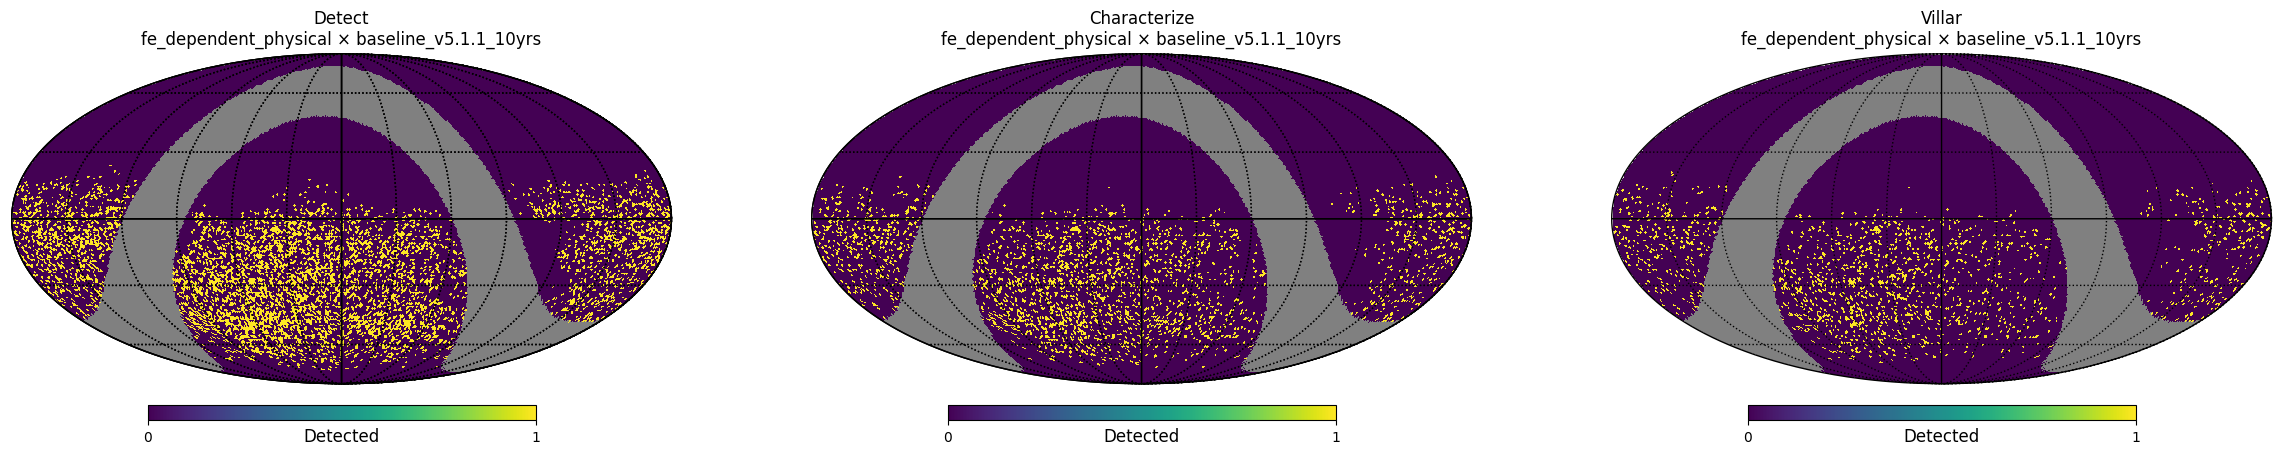

  Saved row: healpix_row_fe_dependent_physical_baseline_v5.1.1_10yrs_physical.png

--- fe_dependent_physical x baseline_v5.3.0_10yrs ---
  detect: 5816 detected pixels / 36418 injected pixels (16.0%)
  characterize: 2972 detected pixels / 36418 injected pixels (8.2%)
  villar: 1901 detected pixels / 36418 injected pixels (5.2%)


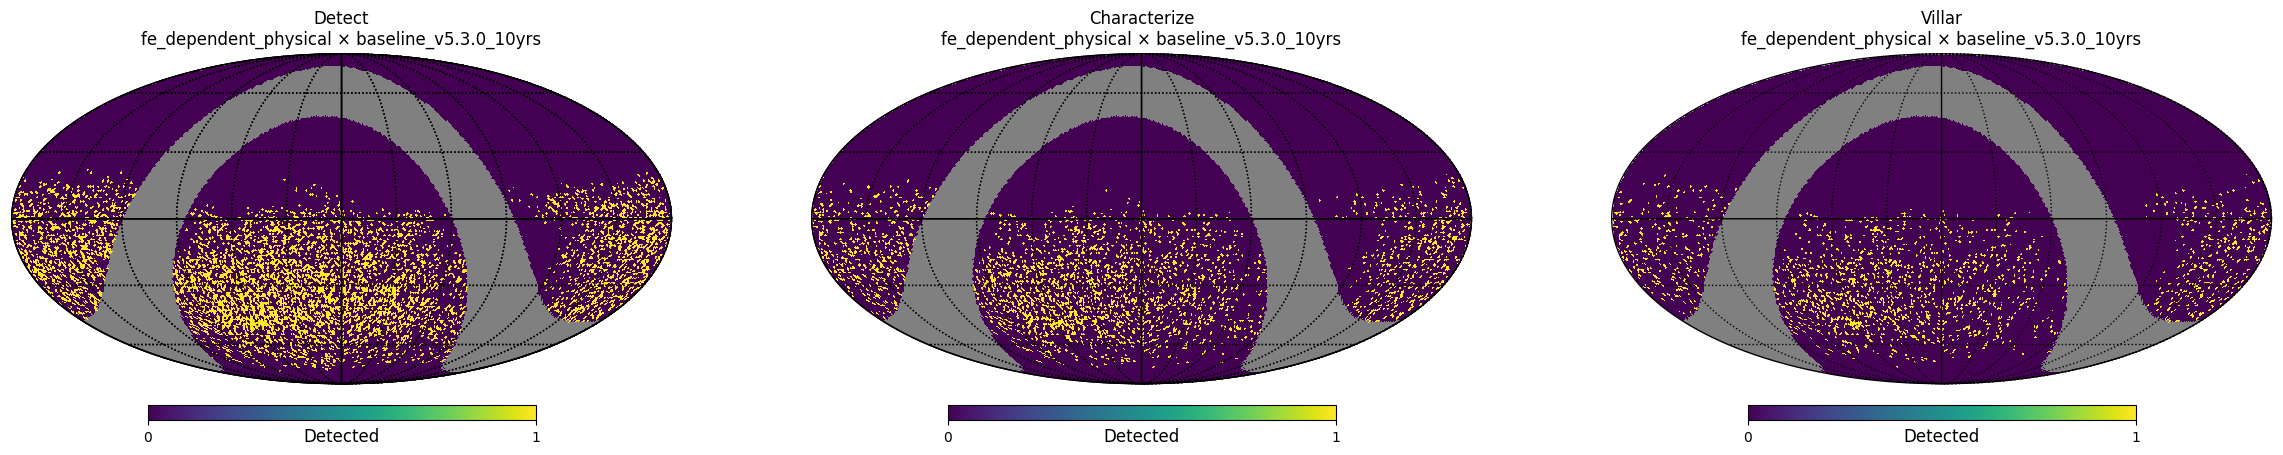

  Saved row: healpix_row_fe_dependent_physical_baseline_v5.3.0_10yrs_physical.png


In [66]:
# ============================================================================
# CELL 16: HEALPix sky maps — all 3 models × all 4 cadences
# Shows detection efficiency per pixel within Rubin observed footprint.
# Grey   = outside injected population (galactic plane + truly empty pixels)
# Purple = injected AND in-footprint (evaluated by MAF), not detected
# Yellow = detected (MAF enforces Rubin footprint)
#
# NOTE: -1 sentinel (out-of-footprint) events are excluded from both
# the purple background and detection count. This makes the Rubin
# footprint boundary visible naturally without an explicit mask.
# ============================================================================
reload(diag_mod)
import healpy as hp

METRIC_KEYS     = ['detect', 'characterize', 'villar']
HEALPIX_FIGSIZE = (24, 4)
NSIDE           = 64
# Toggle — only show cadences with clean badval-fixed npy files
PLOT_CADENCES_9 = ['baseline_v5.1.1_10yrs', 'baseline_v5.3.0_10yrs']
# Z-range for HEALPix map — restrict to a redshift slice to show cadence structure
# At z=3.0-4.0 efficiency drops to ~1-2%, making cadence patterns visible
HEALPIX_Z_RANGE = (3.0, 4.0)  # (z_lo, z_hi) — set to (0.1, 5.0) for full range

def find_latest_npy(model, cadence, metric):
    """Find most recent datestamped z0.1-5.0 npy file for model/cadence/metric."""
    model_dir = get_output_dir('SLSNe', subdir=model)
    pattern = f'metric_values_{metric}_{model}_{cadence}_z0.1-5.0_*.npy'
    files = sorted(model_dir.glob(pattern), key=lambda f: f.stat().st_mtime)
    return files[-1] if files else None

def find_latest_z_values(model, cadence):
    """Find most recent datestamped z0.1-5.0 z_values npy file."""
    model_dir = get_output_dir('SLSNe', subdir=model)
    pattern = f'z_values_{model}_{cadence}_z0.1-5.0_*.npy'
    files = sorted(model_dir.glob(pattern), key=lambda f: f.stat().st_mtime)
    return files[-1] if files else None

for model in MODELS:
    sp    = pop_slicers[model].slice_points
    z_all = np.asarray(sp['z'])

    # Find the most recent z0.1-5.0 npy and verify it matches the full population
    test_npy = find_latest_npy(model, CADENCES[0], 'elasticc')
    if test_npy is None:
        print(f'{model}: no z0.1-5.0 npy found — skipping')
        continue
    test_arr = np.load(str(test_npy))
    if len(test_arr) != (z_all >= 0.1).sum():  # npy always covers z=0.1-5.0 full range
        print(f'{model}: size mismatch — skipping')
        continue

    mask_z  = (z_all >= HEALPIX_Z_RANGE[0]) & (z_all <= HEALPIX_Z_RANGE[1])
    ra_map  = np.asarray(sp['ra'])[mask_z]
    dec_map = np.asarray(sp['dec'])[mask_z]
    print(f'\n{model}: {mask_z.sum():,} events at z={HEALPIX_Z_RANGE[0]}-{HEALPIX_Z_RANGE[1]}')

    # Precompute pixel indices once per model
    npix  = hp.nside2npix(NSIDE)
    theta = 0.5 * np.pi - dec_map
    pix   = hp.ang2pix(NSIDE, theta, ra_map)

    for cadence in PLOT_CADENCES_9:
        print(f'\n--- {model} x {cadence} ---')

        fig = plt.figure(figsize=HEALPIX_FIGSIZE)

        for col_idx, metric in enumerate(METRIC_KEYS):
            npy_path = find_latest_npy(model, cadence, metric)
            if npy_path is None:
                print(f'  Skipping {metric} — no z0.1-5.0 npy found')
                continue

            metric_map   = np.load(str(npy_path))              # full z=0.1-5.0 array
            if len(metric_map) != (z_all >= 0.1).sum():
                print(f'  Size mismatch: npy={len(metric_map)}, '
                      f'pop={(z_all >= 0.1).sum()} — skipping {metric}')
                continue
            metric_slice = metric_map[mask_z]                  # subset matching z-range

           # Build three-layer map:
            # UNSEEN  = no injected events (grey — galactic plane, empty sky)
            # 0.0     = injected but not detected (deep purple)
            # 1.0     = at least one detection (yellow)
            injected_map = np.zeros(npix)   # all injected events
            detected_map = np.zeros(npix)   # detected events

            for i, p in enumerate(pix):
                injected_map[p] += 1
                if metric_slice[i] == 1:
                    detected_map[p] += 1

            eff_map = np.full(npix, hp.UNSEEN)
            eff_map[injected_map > 0] = 0.0   # purple — injected, not detected
            eff_map[detected_map > 0] = 1.0   # yellow — detected

            n_det_pix  = int((detected_map > 0).sum())
            n_inj_pix  = int((injected_map > 0).sum())
            print(f'  {metric}: {n_det_pix} detected pixels / '
                  f'{n_inj_pix} injected pixels '
                  f'({100*n_det_pix/max(n_inj_pix,1):.1f}%)')

            hp.mollview(
                eff_map,
                title  = f'{metric.capitalize()}\n{model} × {cadence}',
                unit   = 'Detected',
                cmap   = 'viridis',
                min    = 0,
                max    = 1,
                hold   = False,
                sub    = (1, len(METRIC_KEYS), col_idx + 1),
                fig    = fig.number
            )
            hp.graticule()

        out_row = get_output_dir('SLSNe', subdir=model) / \
                  f'healpix_row_{model}_{cadence}_physical.png'
        plt.savefig(str(out_row), dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()
        print(f'  Saved row: {out_row.name}')

In [48]:
# Cell 17 - AUDIT TABLE — summary of figure above
# HEALPix detection summary — baseline_v5.1.1 × detect/characterize/villar
# n_in_footprint excludes -1 (out-of-footprint) events; eff = n_det / n_fp
import pandas as pd
_rows11 = []
for _mdl11 in MODELS:
    _sp11 = pop_slicers[_mdl11].slice_points
    _z11  = np.asarray(_sp11['z'])
    _t11  = find_latest_npy(_mdl11, CADENCES[0], 'elasticc')
    if _t11 is None or len(np.load(str(_t11))) != ((_z11 >= 0.1) & (_z11 <= 5.0)).sum():
        continue
    for _met11 in ['detect', 'characterize', 'villar']:
        _npy11 = find_latest_npy(_mdl11, 'baseline_v5.1.1_10yrs', _met11)
        if _npy11 is None:
            continue
        _mv11 = np.load(str(_npy11))
        _fp11 = (_mv11 >= 0).sum()
        _d11  = (_mv11 == 1).sum()
        _rows11.append({'model': _mdl11.replace('_physical',''), 'metric': _met11,
                        'z_max': 5.0, 'n_in_fp': int(_fp11), 'n_detected': int(_d11),
                        'eff_%': round(100 * _d11 / _fp11, 2) if _fp11 > 0 else 0.0})
print("HEALPix detect summary — baseline_v5.1.1  (badval=-1 excluded from denominator)")
print(pd.DataFrame(_rows11).to_string(index=False))

HEALPix detect summary — baseline_v5.1.1  (badval=-1 excluded from denominator)
       model       metric  z_max  n_in_fp  n_detected  eff_%
       naive       detect    5.0  1403725      166309  11.85
       naive characterize    5.0  1403725      135167   9.63
       naive       villar    5.0  1403725      113674   8.10
 o_dependent       detect    5.0  4849474      244718   5.05
 o_dependent characterize    5.0  4849474      191744   3.95
 o_dependent       villar    5.0  4849474      158658   3.27
fe_dependent       detect    5.0  9949104      463034   4.65
fe_dependent characterize    5.0  9949104      356782   3.59
fe_dependent       villar    5.0  9949104      292626   2.94


naive: 2,034,661 events, z=0.1-5.0
o_dependent: 7,033,255 events, z=0.1-5.0
fe_dependent: 14,432,797 events, z=0.1-5.0

=== baseline_v5.1.1_10yrs | detect ===


/users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/py_files/slsn_metrics/diagnostics.py:2658: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  Saved: mc_panel_3panel_detect_baseline_v5.1.1_10yrs.png


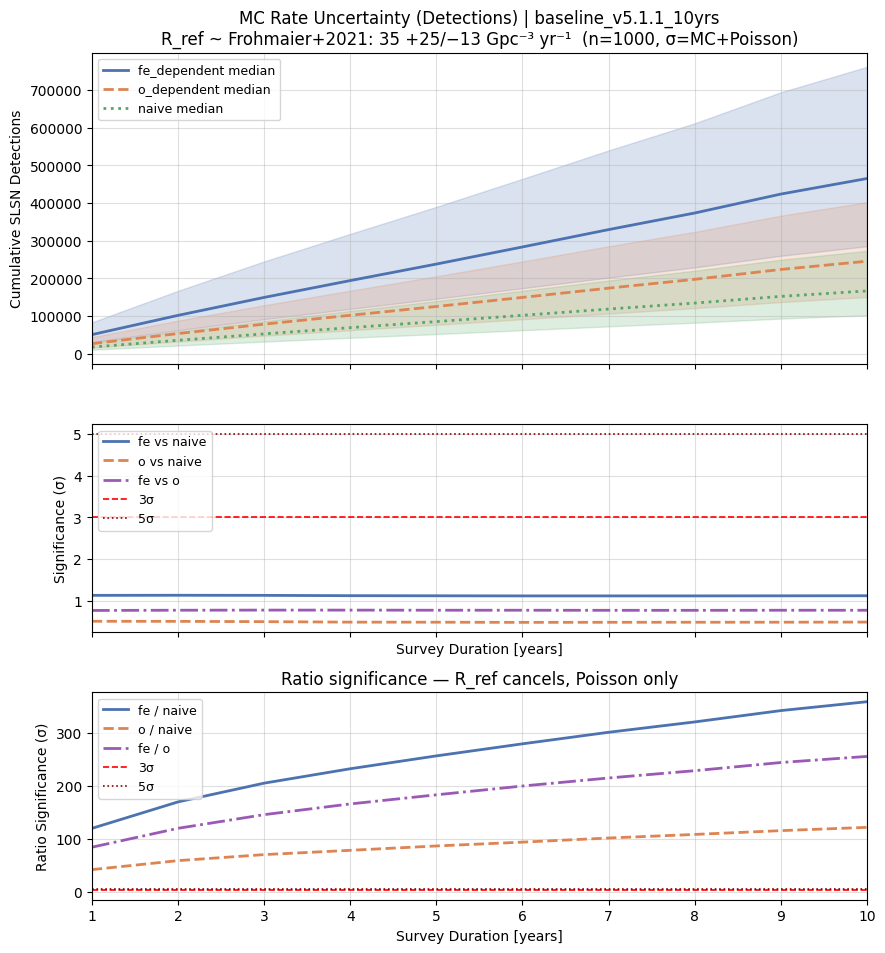


=== baseline_v5.3.0_10yrs | detect ===
  Saved: mc_panel_3panel_detect_baseline_v5.3.0_10yrs.png


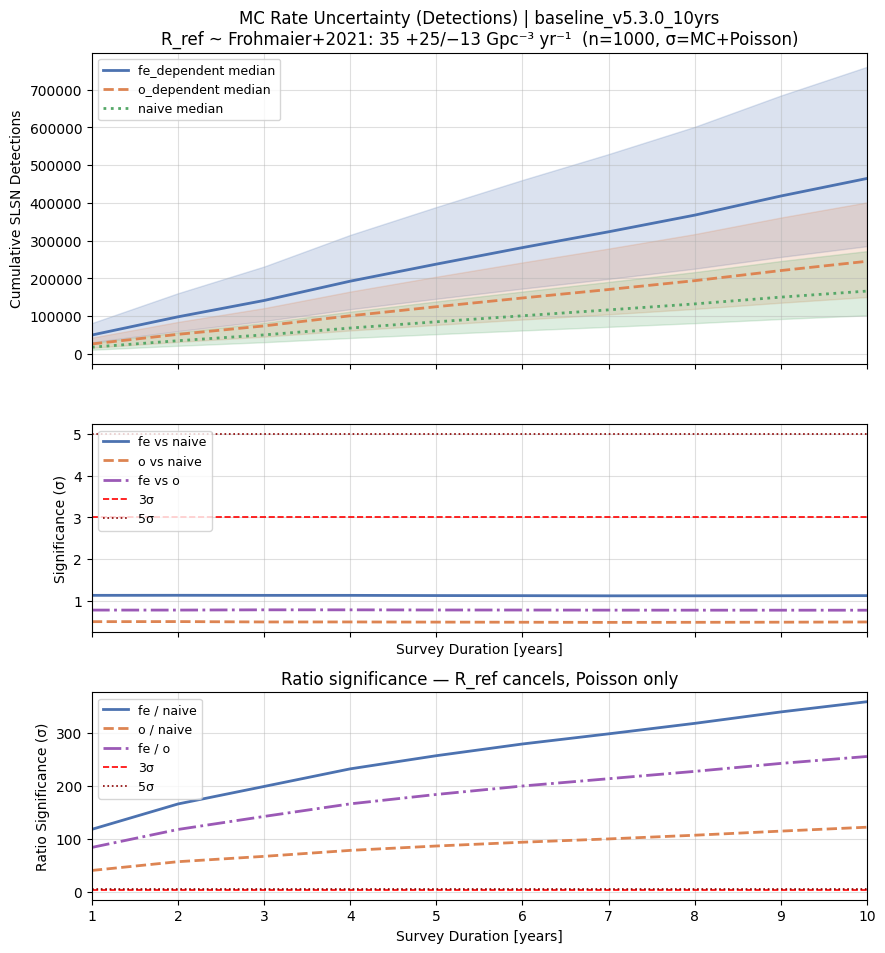

In [49]:
# ============================================================================
# CELL 18 - MC: Monte Carlo rate uncertainty — all cadences, all models
# ============================================================================
import slsn_metrics.diagnostics as diag_mod
from importlib import reload
reload(diag_mod)
from slsn_metrics.diagnostics import plot_mc_rate_uncertainty_panel

METRIC_KEY   = 'detect'
METRIC_LABEL = {
    'detect':       'Detections',
    'characterize': 'Characterized',
    'villar':       'Villar Detections',
    'elasticc':     'ELAsTiCC Detections',
}[METRIC_KEY]

MODEL_SHORT = {
    'naive_physical':        'naive',
    'o_dependent_physical':  'o_dependent',
    'fe_dependent_physical': 'fe_dependent',
}

def find_latest_npy(model, cadence, metric):
    """Find most recent datestamped z0.1-5.0 npy file for model/cadence/metric."""
    model_dir = get_output_dir('SLSNe', subdir=model)
    pattern = f'metric_values_{metric}_{model}_{cadence}_z0.1-5.0_*.npy'
    files = sorted(model_dir.glob(pattern), key=lambda f: f.stat().st_mtime)
    return files[-1] if files else None

def find_latest_z_values(model, cadence):
    """Find most recent datestamped z0.1-5.0 z_values npy file."""
    model_dir = get_output_dir('SLSNe', subdir=model)
    pattern = f'z_values_{model}_{cadence}_z0.1-5.0_*.npy'
    files = sorted(model_dir.glob(pattern), key=lambda f: f.stat().st_mtime)
    return files[-1] if files else None

pop_data_mc = {}
for model in MODELS:
    short = MODEL_SHORT[model]
    sp    = pop_slicers[model].slice_points
    z_all = np.asarray(sp['z'])

    # Find the most recent z0.1-5.0 npy and verify it matches the full population
    test_npy = find_latest_npy(model, CADENCES[0], 'elasticc')
    if test_npy is None:
        print(f'{model}: no z0.1-5.0 npy found — skipping')
        continue
    test_arr = np.load(str(test_npy))
    mask_z   = (z_all >= 0.1) & (z_all <= 5.0)
    if len(test_arr) != mask_z.sum():
        print(f'{model}: size mismatch (npy={len(test_arr):,}, pop={mask_z.sum():,}) — skipping')
        continue

    peak_times = np.asarray(sp['peak_time'])[mask_z]
    z_vals     = z_all[mask_z]

    # Load per-cadence .npy arrays for this metric
    metric_arrays = {}
    for cadence in CADENCES:
        npy_path = find_latest_npy(model, cadence, METRIC_KEY)
        if npy_path is not None:
            arr = np.load(str(npy_path)).astype(int)
            if len(arr) == len(peak_times):
                metric_arrays[cadence] = arr
            else:
                print(f'  Size mismatch {model} {cadence}: '
                      f'npy={len(arr):,} vs peak_times={len(peak_times):,}')
                metric_arrays[cadence] = None
        else:
            print(f'  Missing: no z0.1-5.0 npy for {model} {cadence} {METRIC_KEY}')
            metric_arrays[cadence] = None

    pop_data_mc[short] = {
        METRIC_KEY:   metric_arrays,
        'peak_time':  peak_times,
        'z':          z_vals,
    }
    print(f'{short}: {len(peak_times):,} events, z=0.1-5.0')

# Run MC panel for each cadence
SAVE_DIR = get_output_dir('SLSNe')
for cadence in CADENCES:
    print(f'\n=== {cadence} | {METRIC_KEY} ===')
    plot_mc_rate_uncertainty_panel(
        pop_data       = pop_data_mc,
        cadence        = cadence,
        metric_key     = METRIC_KEY,
        metric_label   = METRIC_LABEL,
        R_ref_nominal  = 35.0,
        n_realizations = 1000,
        seed           = 42,
        save_dir       = SAVE_DIR,
    )

In [50]:
# Cell 19: AUDIT TABLE — summary of figure above
# BUG: detect_vals arrays contain -1 (out-of-footprint badval sentinel).
# plot_mc_rate_uncertainty_panel calls detect_vals.sum() which includes -1 values,
# making base_cumulative negative and the plotted MC curves deeply negative.
# FIX NEEDED: mask with (detect_vals >= 0) before summing.
import pandas as pd
_rows13 = []
_cad13  = 'baseline_v5.1.1_10yrs'
for _ms13, _md13 in pop_data_mc.items():
    _arr13 = _md13['detect'].get(_cad13)
    if _arr13 is None:
        continue
    _n13   = len(_arr13)
    _det13 = int((_arr13 == 1).sum())
    _mis13 = int((_arr13 == 0).sum())
    _bad13 = int((_arr13 == -1).sum())
    _rows13.append({
        'model':           _ms13,
        'n_injected':      _n13,
        'detected_+1':     _det13,
        'missed_0':        _mis13,
        'badval_-1':       _bad13,
        'raw_sum (BUG)':   int(_arr13.sum()),
        'correct_sum':     _det13,
    })
_tbl13 = pd.DataFrame(_rows13)
print(f"MC detect array breakdown — {_cad13}")
print("raw_sum = what the MC panel uses as base_cumulative[yr=10]  <-- SOURCE OF NEGATIVE CURVES")
print("correct_sum = n_detected (+1 only) = what the 10-yr count should be")
print(_tbl13.to_string(index=False))

MC detect array breakdown — baseline_v5.1.1_10yrs
raw_sum = what the MC panel uses as base_cumulative[yr=10]  <-- SOURCE OF NEGATIVE CURVES
correct_sum = n_detected (+1 only) = what the 10-yr count should be
       model  n_injected  detected_+1  missed_0  badval_-1  raw_sum (BUG)  correct_sum
       naive     2034661       166309   1237416     630936        -464627       166309
 o_dependent     7033255       244718   4604756    2183781       -1939063       244718
fe_dependent    14432797       463034   9486070    4483693       -4020659       463034



MODEL: Naive SFR (Physical)

  Cadence: Baseline v5.3.0
         z-bin   n_events        ELAsTiCC          Detect    Characterize          Villar
  ---------------------------------------------------------------------------------------
  [0.1,0.2)         564    362 ( 64.2%)    348 ( 61.7%)    343 ( 60.8%)    334 ( 59.2%)
  [0.2,0.3)       1,735   1110 ( 64.0%)   1040 ( 59.9%)   1003 ( 57.8%)    966 ( 55.7%)
  [0.3,0.4)       3,492   2203 ( 63.1%)   2020 ( 57.8%)   1905 ( 54.6%)   1805 ( 51.7%)
  [0.4,0.5)       6,309   3816 ( 60.5%)   3409 ( 54.0%)   3187 ( 50.5%)   2962 ( 46.9%)
  [0.5,0.6)       9,755   5817 ( 59.6%)   4997 ( 51.2%)   4635 ( 47.5%)   4237 ( 43.4%)
  [0.6,0.7)      14,472   8102 ( 56.0%)   6726 ( 46.5%)   6140 ( 42.4%)   5486 ( 37.9%)
  [0.7,0.8)      19,744  10419 ( 52.8%)   8395 ( 42.5%)   7556 ( 38.3%)   6703 ( 33.9%)
  [0.8,0.9)      25,776  13076 ( 50.7%)  10160 ( 39.4%)   9006 ( 34.9%)   7956 ( 30.9%)
  [0.9,1.0)      32,268  15228 ( 47.2%)  11297 ( 35.0%)   9

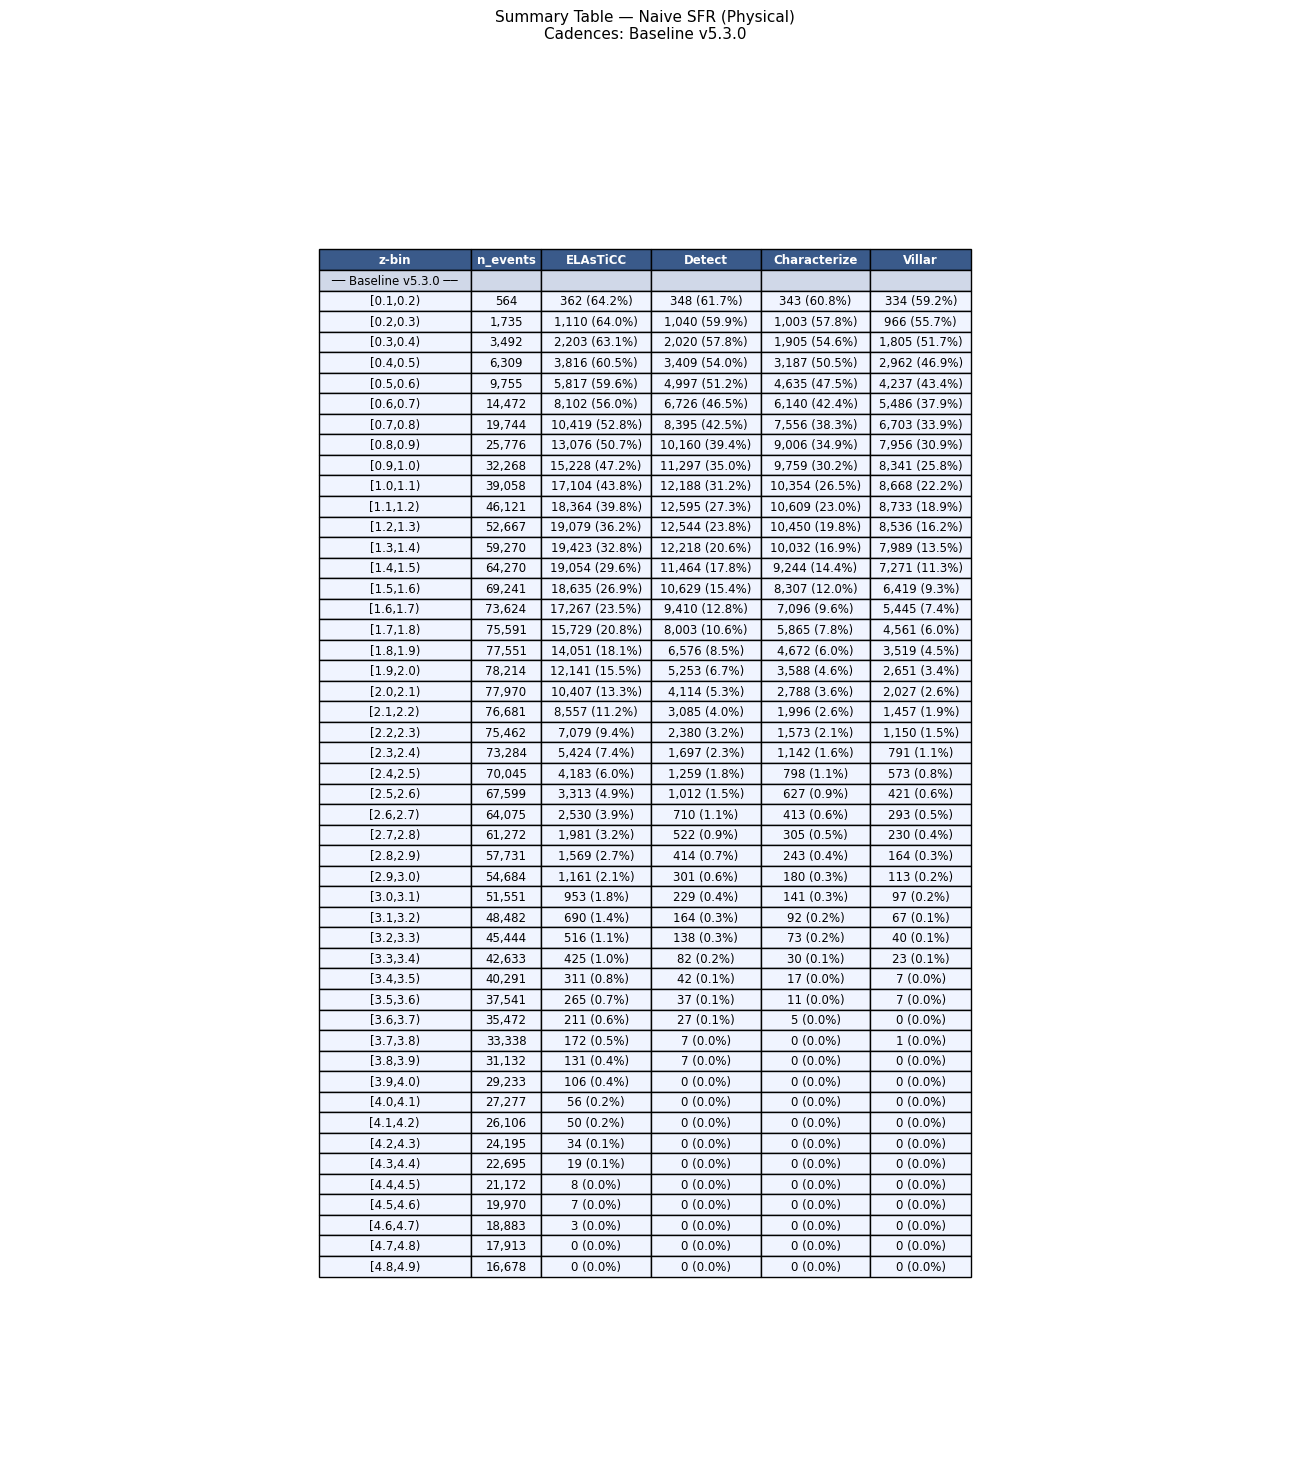


MODEL: O-dependent (Physical)

  Cadence: Baseline v5.3.0
         z-bin   n_events        ELAsTiCC          Detect    Characterize          Villar
  ---------------------------------------------------------------------------------------
  [0.1,0.2)         630    425 ( 67.5%)    408 ( 64.8%)    391 ( 62.1%)    384 ( 61.0%)
  [0.2,0.3)       1,728   1114 ( 64.5%)   1042 ( 60.3%)    993 ( 57.5%)    949 ( 54.9%)
  [0.3,0.4)       3,589   2242 ( 62.5%)   2074 ( 57.8%)   1980 ( 55.2%)   1888 ( 52.6%)
  [0.4,0.5)       6,335   3902 ( 61.6%)   3488 ( 55.1%)   3275 ( 51.7%)   3023 ( 47.7%)
  [0.5,0.6)      10,040   5947 ( 59.2%)   5122 ( 51.0%)   4722 ( 47.0%)   4315 ( 43.0%)
  [0.6,0.7)      14,640   8270 ( 56.5%)   6895 ( 47.1%)   6273 ( 42.8%)   5657 ( 38.6%)
  [0.7,0.8)      20,551  10942 ( 53.2%)   8851 ( 43.1%)   7992 ( 38.9%)   7003 ( 34.1%)
  [0.8,0.9)      27,682  13850 ( 50.0%)  10735 ( 38.8%)   9418 ( 34.0%)   8156 ( 29.5%)
  [0.9,1.0)      35,795  16784 ( 46.9%)  12488 ( 34.9%)  

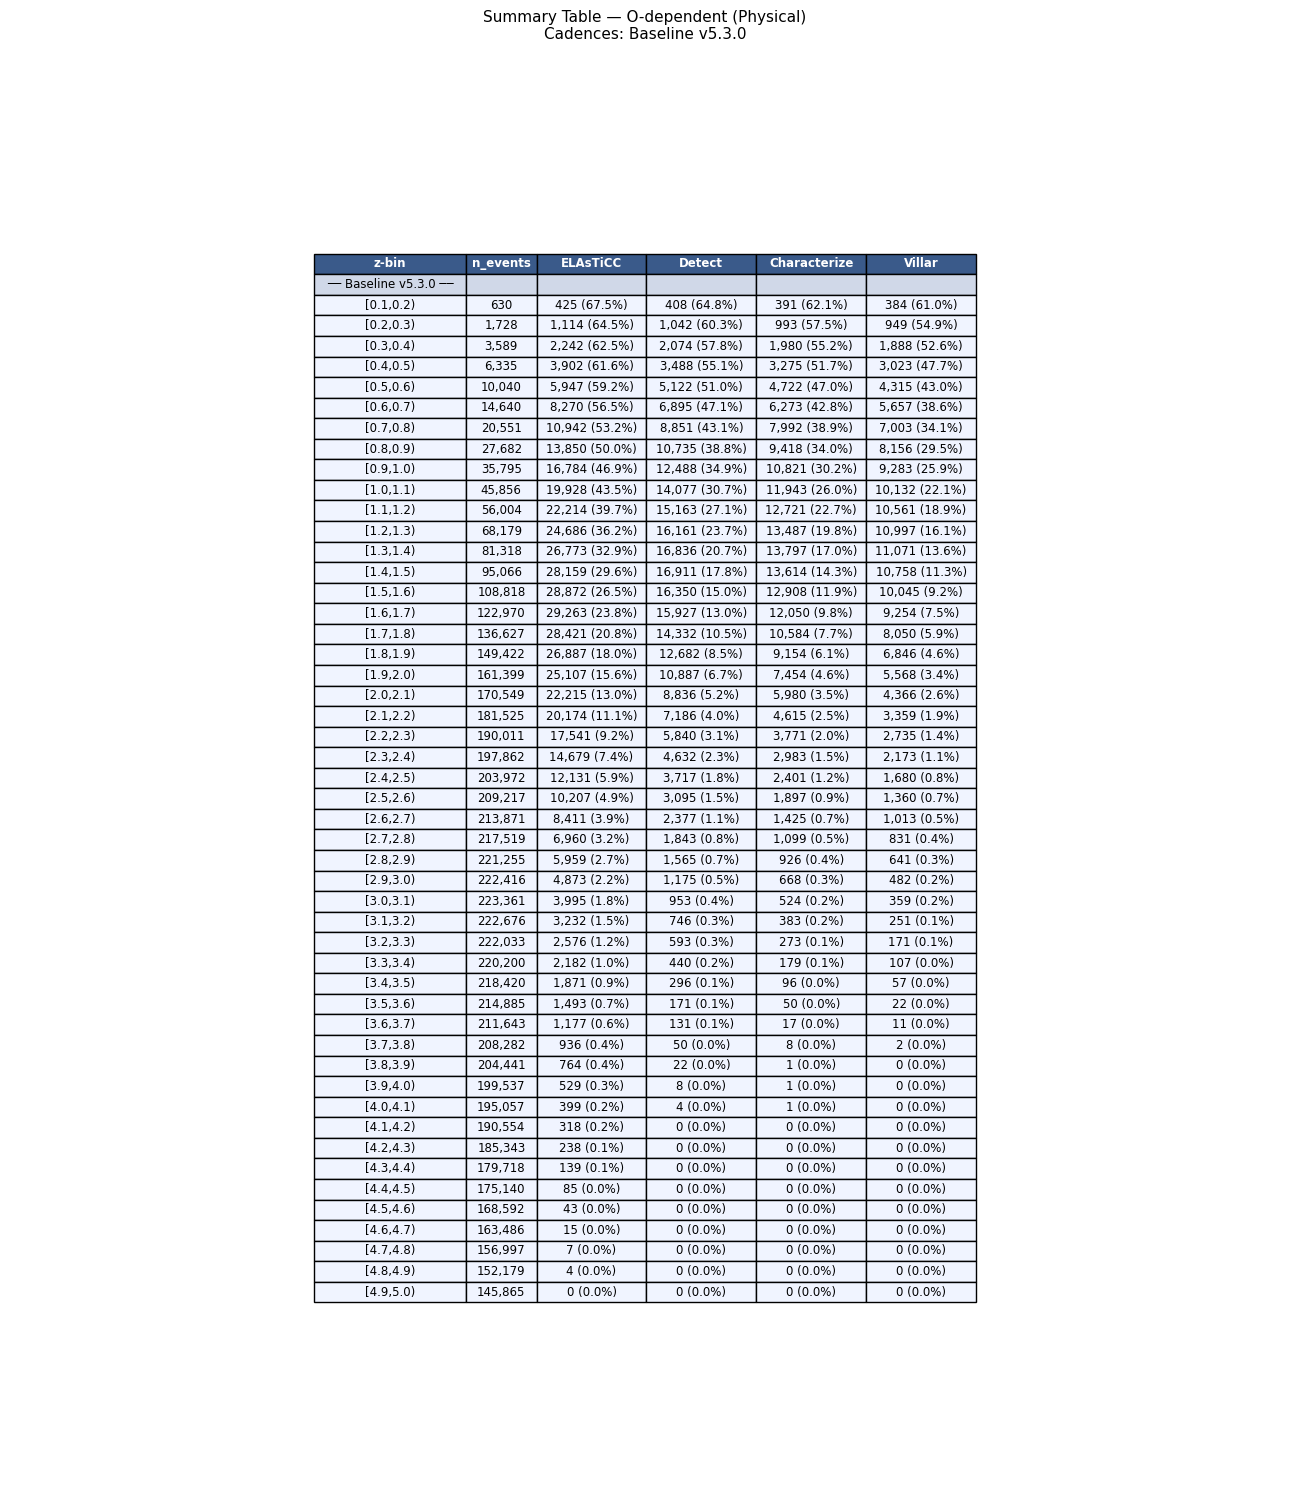


MODEL: Fe-dependent (Physical)

  Cadence: Baseline v5.3.0
         z-bin   n_events        ELAsTiCC          Detect    Characterize          Villar
  ---------------------------------------------------------------------------------------
  [0.1,0.2)         607    409 ( 67.4%)    397 ( 65.4%)    384 ( 63.3%)    356 ( 58.6%)
  [0.2,0.3)       1,775   1133 ( 63.8%)   1080 ( 60.8%)   1041 ( 58.6%)    995 ( 56.1%)
  [0.3,0.4)       4,116   2559 ( 62.2%)   2330 ( 56.6%)   2210 ( 53.7%)   2071 ( 50.3%)
  [0.4,0.5)       7,873   4758 ( 60.4%)   4300 ( 54.6%)   4036 ( 51.3%)   3758 ( 47.7%)
  [0.5,0.6)      13,299   7923 ( 59.6%)   6827 ( 51.3%)   6326 ( 47.6%)   5759 ( 43.3%)
  [0.6,0.7)      20,555  11534 ( 56.1%)   9690 ( 47.1%)   8828 ( 42.9%)   7851 ( 38.2%)
  [0.7,0.8)      30,694  16477 ( 53.7%)  13336 ( 43.4%)  12027 ( 39.2%)  10557 ( 34.4%)
  [0.8,0.9)      43,470  21827 ( 50.2%)  17069 ( 39.3%)  15070 ( 34.7%)  13128 ( 30.2%)
  [0.9,1.0)      59,558  28132 ( 47.2%)  20864 ( 35.0%) 

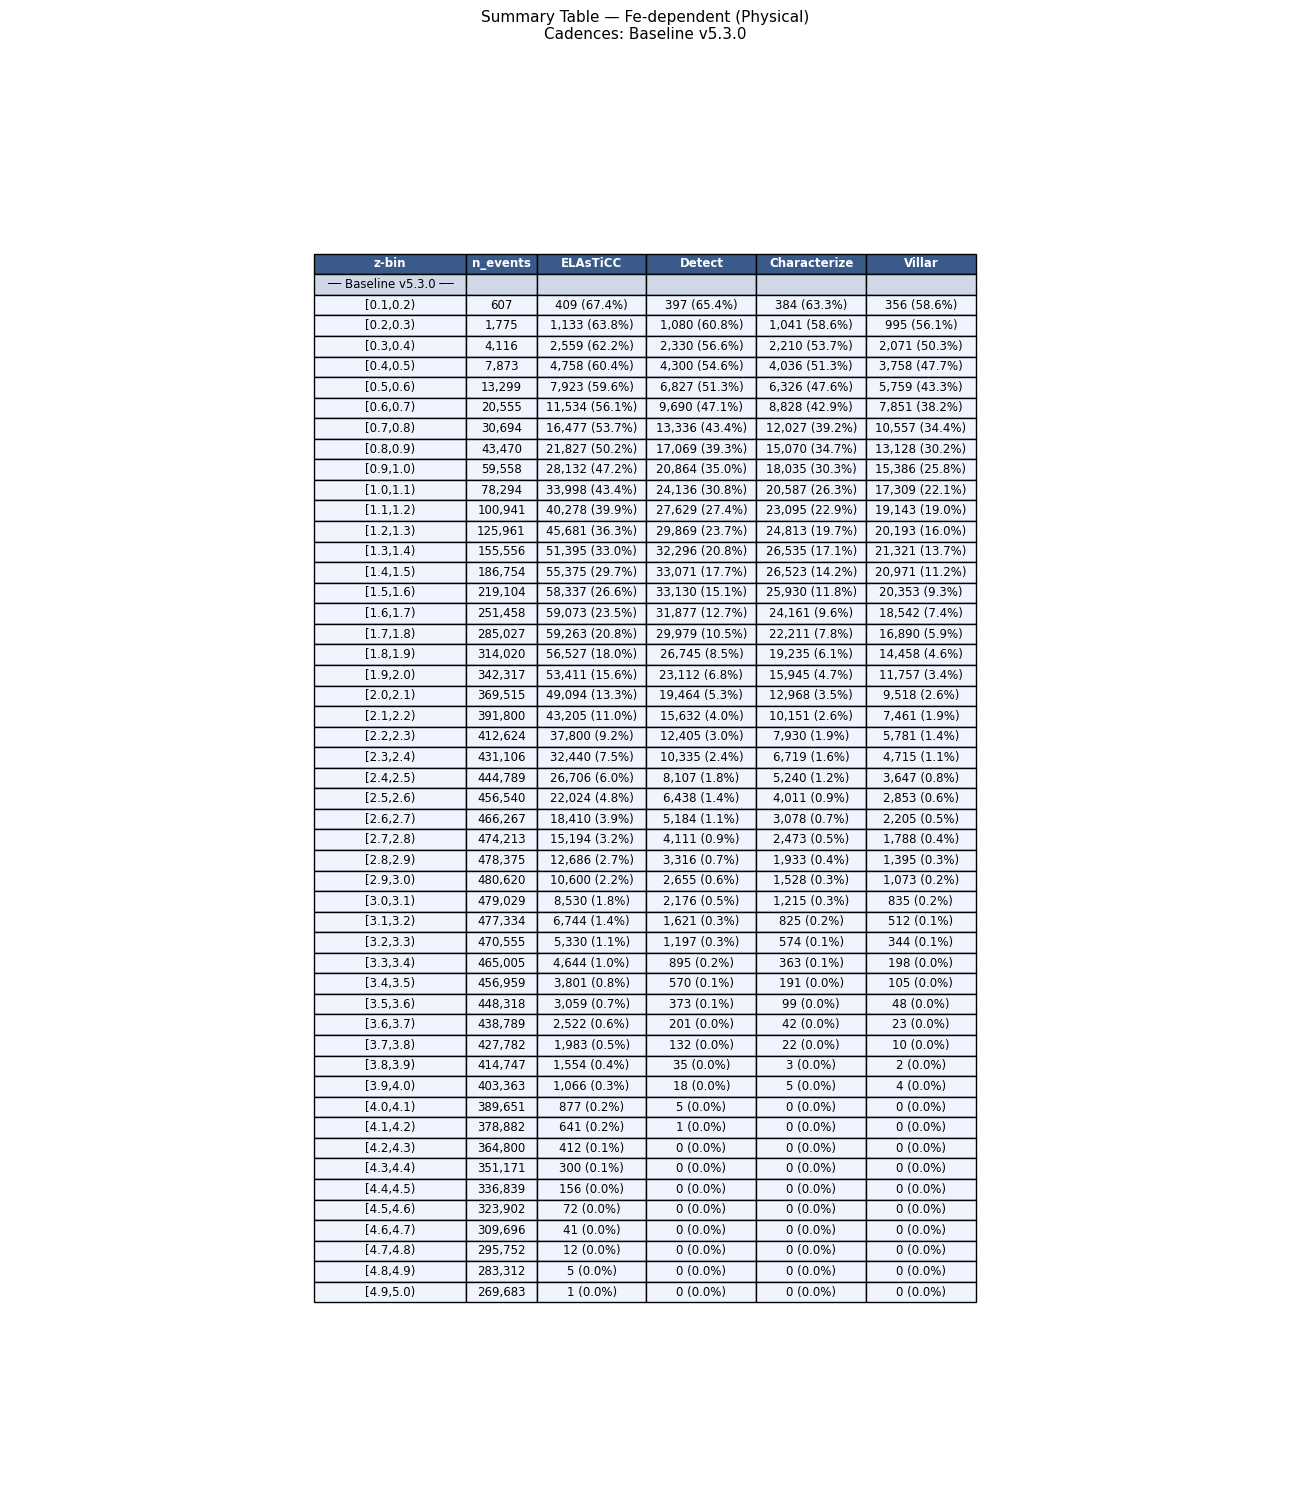

In [51]:
# ============================================================================
# CELL 20: Summary tables — one per model, cadences as row groups
# Rows = z-bins, Columns = metrics
# Shows n_success (efficiency%)
# Saves one PNG per model
# ============================================================================

# Toggles
PLOT_CADENCES_11 = ['baseline_v5.3.0_10yrs']  # or e.g. ['baseline_v5.3.0_10yrs']

METRIC_DISPLAY = {
    'SLSN_ELAsTiCC_Metric':              'ELAsTiCC',
    'SLSN_Detect_Physical_Metric':       'Detect',
    'SLSN_Characterize_Physical_Metric': 'Characterize',
    'SLSN_Villar_Physical_Metric':       'Villar',
}
METRIC_ORDER = list(METRIC_DISPLAY.keys())
CADENCE_LABELS = {
    'baseline_v5.1.1_10yrs':    'Baseline v5.1.1',
    'baseline_v5.3.0_10yrs':    'Baseline v5.3.0',
    'noroll_v5.0.0_10yrs':      'No Roll',
    'poor_weather_v5.0.1_10yrs':'Poor Weather',
}

for model in MODELS:
    df = ADAPTIVE[model].copy()
    z_bins = sorted(df[['z_lo','z_hi']].drop_duplicates().values.tolist())

    # ----------------------------------------------------------------
    # 1. Print to terminal (unchanged)
    # ----------------------------------------------------------------
    print(f"\n{'='*90}")
    print(f"MODEL: {model_labels[model]}")
    print(f"{'='*90}")

    for cadence in PLOT_CADENCES_11:
        print(f"\n  Cadence: {CADENCE_LABELS.get(cadence, cadence)}")
        header = f"  {'z-bin':>12} {'n_events':>10}"
        for m in METRIC_ORDER:
            header += f"  {METRIC_DISPLAY[m]:>14}"
        print(header)
        print("  " + "-" * (len(header) - 2))

        for z_lo, z_hi in z_bins:
            row_data = df[
                (df['z_lo'] == z_lo) &
                (df['z_hi'] == z_hi) &
                (df['cadence'] == cadence)
            ]
            if row_data.empty:
                continue
            n_ev = int(row_data['n_events'].iloc[0])
            row_str = f"  [{z_lo:.1f},{z_hi:.1f})  {n_ev:>10,}"
            for m in METRIC_ORDER:
                mrow = row_data[row_data['metric'] == m]
                if mrow.empty:
                    row_str += f"  {'—':>14}"
                else:
                    n_suc = int(mrow['n_success'].iloc[0])
                    eff   = float(mrow['efficiency'].iloc[0]) * 100
                    row_str += f"  {n_suc:>5} ({eff:>5.1f}%)"
            print(row_str)

    # ----------------------------------------------------------------
    # 2. Build table data for matplotlib
    # ----------------------------------------------------------------
    col_headers = ['z-bin', 'n_events'] + [METRIC_DISPLAY[m] for m in METRIC_ORDER]

    all_rows  = []   # table data
    all_colors = []  # row background colors

    # Alternating cadence section colors
    section_colors = ['#f0f4ff', '#fff8f0']

    for ci, cadence in enumerate(PLOT_CADENCES_11):
        sec_color = section_colors[ci % 2]
        cad_label = CADENCE_LABELS.get(cadence, cadence)

        # Cadence header row
        header_row = [f'── {cad_label} ──'] + [''] * (len(col_headers) - 1)
        all_rows.append(header_row)
        all_colors.append(['#d0d8e8'] * len(col_headers))

        for z_lo, z_hi in z_bins:
            row_data = df[
                (df['z_lo'] == z_lo) &
                (df['z_hi'] == z_hi) &
                (df['cadence'] == cadence)
            ]
            if row_data.empty:
                continue

            n_ev = int(row_data['n_events'].iloc[0])
            row = [f'[{z_lo:.1f},{z_hi:.1f})', f'{n_ev:,}']

            for m in METRIC_ORDER:
                mrow = row_data[row_data['metric'] == m]
                if mrow.empty:
                    row.append('—')
                else:
                    n_suc = int(mrow['n_success'].iloc[0])
                    eff   = float(mrow['efficiency'].iloc[0]) * 100
                    row.append(f'{n_suc:,} ({eff:.1f}%)')

            all_rows.append(row)
            all_colors.append([sec_color] * len(col_headers))

    # ----------------------------------------------------------------
    # 3. Render and save
    # ----------------------------------------------------------------
    n_rows = len(all_rows)
    fig_h  = max(4, 0.28 * n_rows + 1.2)
    fig, ax = plt.subplots(figsize=(13, fig_h))
    ax.axis('off')

    tbl = ax.table(
        cellText=all_rows,
        colLabels=col_headers,
        cellLoc='center',
        loc='center',
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8.5)
    tbl.auto_set_column_width(col=list(range(len(col_headers))))

    # Apply row colors
    for (row_idx, col_idx), cell in tbl.get_celld().items():
        if row_idx == 0:
            cell.set_facecolor('#3a5a8a')
            cell.set_text_props(color='white', fontweight='bold')
        else:
            cell.set_facecolor(all_colors[row_idx - 1][col_idx])

    ax.set_title(
        f'Summary Table — {model_labels[model]}\n'
        f'Cadences: {", ".join(CADENCE_LABELS.get(c,c) for c in PLOT_CADENCES_11)}',
        fontsize=11, pad=12
    )

    plt.tight_layout()
    out_fig = get_output_dir('SLSNe') / f'summary_table_{model}.png'
    plt.savefig(out_fig, dpi=150, bbox_inches='tight')
    print(f'\nSaved: {out_fig.name}')
    plt.show()

In [52]:
# Cell 21 - AUDIT TABLE — summary of figure above
# Detect metric: n_success and efficiency per z-bin — baseline_v5.3.0 only
# Non-zero bins only; matches the figure's PLOT_CADENCES_11 = ['baseline_v5.3.0_10yrs']
import pandas as pd
_rows14 = []
for _mdl14 in MODELS:
    _df14 = ADAPTIVE[_mdl14]
    _sub14 = _df14[
        (_df14['cadence'] == 'baseline_v5.3.0_10yrs') &
        (_df14['metric'] == 'SLSN_Detect_Physical_Metric') &
        (_df14['n_success'] > 0)
    ][['z_lo','z_hi','n_events','n_success','efficiency']].copy()
    _sub14.insert(0, 'model', _mdl14.replace('_physical',''))
    _sub14['eff_%'] = (_sub14['efficiency'] * 100).round(1)
    _rows14.append(_sub14)
_tbl14 = pd.concat(_rows14, ignore_index=True)
print("Detect efficiency summary — baseline_v5.3.0 (non-zero z-bins only)")
print(_tbl14[['model','z_lo','z_hi','n_events','n_success','eff_%']].to_string(index=False))

Detect efficiency summary — baseline_v5.3.0 (non-zero z-bins only)
       model  z_lo  z_hi  n_events  n_success  eff_%
       naive   0.1   0.2       564        348   61.7
       naive   0.2   0.3      1735       1040   59.9
       naive   0.3   0.4      3492       2020   57.8
       naive   0.4   0.5      6309       3409   54.0
       naive   0.5   0.6      9755       4997   51.2
       naive   0.6   0.7     14472       6726   46.5
       naive   0.7   0.8     19744       8395   42.5
       naive   0.8   0.9     25776      10160   39.4
       naive   0.9   1.0     32268      11297   35.0
       naive   1.0   1.1     39058      12188   31.2
       naive   1.1   1.2     46121      12595   27.3
       naive   1.2   1.3     52667      12544   23.8
       naive   1.3   1.4     59270      12218   20.6
       naive   1.4   1.5     64270      11464   17.8
       naive   1.5   1.6     69241      10629   15.4
       naive   1.6   1.7     73624       9410   12.8
       naive   1.7   1.8     755

Saved: sed_peak_suppression_2019qgk.png
Event: 2019qgk
MOSFiT lambda_0 = 5335.3 A, alpha = 0.7974
Visual departure edge = 1814 A


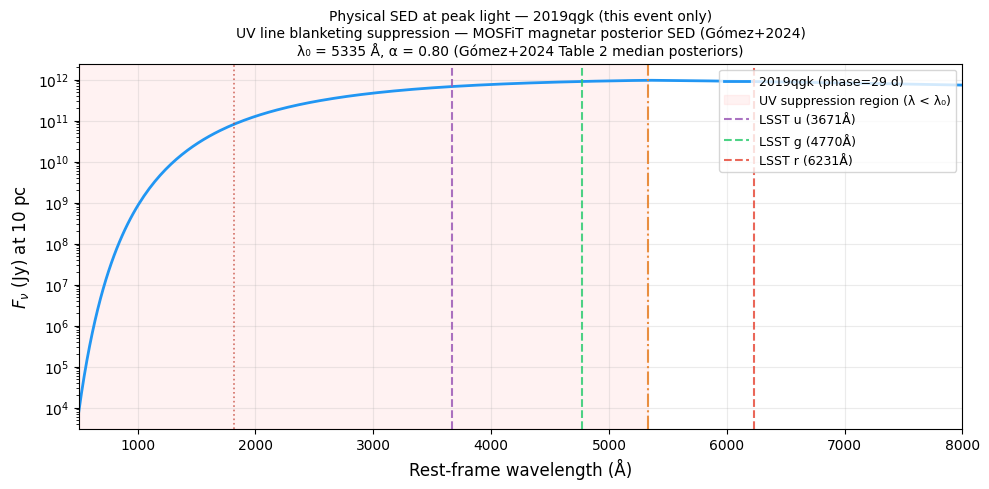

In [53]:
# ============================================================================
# CELL 22: SED at peak light — UV line blanketing suppression
# Shows physical SED Fnu vs rest-frame wavelength for one event at peak
# Illustrates why g-band fails at high z (UV suppression)
# ============================================================================
# Reload flags:
#   Templates  : NO — loads physical_templates.pkl directly
#   Population : NO
#   Mag grid   : NO
#   Kernel     : NO
#
# Toggles
EVENT_IDX  = 100   # index into sed_grid/names (0–264); 100 = 2019qgk
SHOW_ANNOT = True  # show suppression edge annotation

import joblib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

# Load physical templates
tpl_path  = get_output_dir('SLSNe', subdir='shared') / 'physical_templates.pkl'
templates = joblib.load(tpl_path)
sg        = templates['sed_grid']
names     = templates['names']

# --- Select event and find peak phase ---
s         = sg[EVENT_IDX]
event_name = names[EVENT_IDX]
lam        = s['lam_rest_A']          # (500,) Angstroms
fnu        = s['Fnu_abs']             # (161, 500) Jy at 10 pc
phase      = s['phase']               # (161,) days

total_flux = fnu.sum(axis=1)
peak_idx   = np.argmax(total_flux)
peak_phase = phase[peak_idx]
fnu_peak   = fnu[peak_idx, :]        # (500,) Jy at peak

# --- Load MOSFiT posterior parameters for this event ---
params_path = get_output_dir('SLSNe').parent / 'all_events' / 'allparameter.csv'
params_df   = pd.read_csv(params_path)
event_row   = params_df[params_df['name'] == event_name]
if len(event_row) > 0:
    mosfit_lambda0 = float(event_row['cutoff_wavelength_med'].iloc[0])
    mosfit_alpha   = float(event_row['alpha_med'].iloc[0])
else:
    mosfit_lambda0 = None
    mosfit_alpha   = None
    print(f'Warning: {event_name} not found in allparameter.csv')

# --- Visual suppression edge: wavelength where flux drops to 10%
#     of optical mean. This is NOT the MOSFiT lambda_0 parameter —
#     it is the observed departure from the Planck curve. ---
opt_mask   = (lam >= 3000) & (lam < 8000)
opt_mean   = fnu_peak[opt_mask].mean()
supp_candidates = lam[(fnu_peak < 0.1 * opt_mean) & (lam < 4000)]
supp_edge  = supp_candidates.max() if len(supp_candidates) > 0 else None

# --- LSST filter centers (Angstroms) ---
lsst_centers = {
    'u': 3671,
    'g': 4770,
    'r': 6231,
}
lsst_colors = {'u': '#9b59b6', 'g': '#2ecc71', 'r': '#e74c3c'}

# --- Plot ---
LAM_MIN, LAM_MAX = 500, 8000
mask_plot = (lam >= LAM_MIN) & (lam <= LAM_MAX)

fig, ax = plt.subplots(figsize=(10, 5))

# SED line
ax.semilogy(lam[mask_plot], fnu_peak[mask_plot],
            color='#2196F3', lw=2.0,
            label=f'{event_name} (phase={peak_phase:.0f} d)')

# UV suppression shaded region — extends to MOSFiT lambda_0
# Everything blueward of lambda_0 is suppressed by the power law
supp_max = mosfit_lambda0 if mosfit_lambda0 is not None else 3000
ax.axvspan(LAM_MIN, supp_max, color='#ffcccc', alpha=0.25,
           label=f'UV suppression region (λ < λ₀)')

# LSST filter center lines
for fname, fcen in lsst_centers.items():
    ax.axvline(fcen, color=lsst_colors[fname], lw=1.5,
               ls='--', alpha=0.85, label=f'LSST {fname} ({fcen}Å)')

if SHOW_ANNOT:
    # Annotation 1: visual departure from Planck curve
    if supp_edge is not None:
        ax.axvline(supp_edge, color='#c0392b', lw=1.2, ls=':', alpha=0.7)
        ax.annotate(
            f'Visual departure from\nPlanck curve (~{supp_edge:.0f} Å)',
            xy=(supp_edge, 1e2),
            xytext=(supp_edge + 400, 1e3),
            fontsize=8, color='#c0392b',
            arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.0),
        )

    # Annotation 2: MOSFiT lambda_0
    if mosfit_lambda0 is not None:
        ax.axvline(mosfit_lambda0, color='#e67e22', lw=1.5, ls='-.', alpha=0.85)
        ax.annotate(
            f'MOSFiT λ₀ = {mosfit_lambda0:.0f} Å\n(α = {mosfit_alpha:.2f})',
            xy=(mosfit_lambda0, 1e3),
            xytext=(mosfit_lambda0 - 2500, 1e2),
            fontsize=8, color='#e67e22',
            arrowprops=dict(arrowstyle='->', color='#e67e22', lw=1.0),
        )

ax.set_xlim(LAM_MIN, LAM_MAX)
ax.set_xlabel('Rest-frame wavelength (Å)', fontsize=12)
ax.set_ylabel(r'$F_\nu$ (Jy) at 10 pc', fontsize=12)
ax.set_title(
    f'Physical SED at peak light — {event_name} (this event only)\n'
    f'UV line blanketing suppression — MOSFiT magnetar posterior SED '
    f'(Gómez+2024)\n'
    f'λ₀ = {mosfit_lambda0:.0f} Å, α = {mosfit_alpha:.2f} '
    f'(Gómez+2024 Table 2 median posteriors)',
    fontsize=10
)
ax.legend(fontsize=9, loc='upper right')
ax.grid(alpha=0.25)

plt.tight_layout()
out_fig = get_output_dir('SLSNe') / f'sed_peak_suppression_{event_name}.png'
plt.savefig(out_fig, dpi=150, bbox_inches='tight')
print(f'Saved: {out_fig.name}')
print(f'Event: {event_name}')
print(f'MOSFiT lambda_0 = {mosfit_lambda0:.1f} A, alpha = {mosfit_alpha:.4f}')
print(f'Visual departure edge = {supp_edge:.0f} A' if supp_edge else 'No visual edge found')
plt.show()

In [54]:
# Cell 23 - AUDIT TABLE — summary of figure above
# Physical SED for 2019qgk at peak: Fnu at LSST filter centers + UV wavelengths
# Suppression edge = wavelength where Fnu < 10% of optical mean (Fnu[3000-8000Å])
import pandas as pd
_wls15   = sorted(list(lsst_centers.values()) + [1500, 2000, 2500, 3000])
_rows15  = []
for _wl15 in _wls15:
    _idx15 = np.argmin(np.abs(lam - _wl15))
    _filt15 = next((f'LSST-{k}' for k, v in lsst_centers.items() if v == _wl15), '—')
    _rows15.append({'lam_A': int(lam[_idx15]), 'filter': _filt15,
                    'Fnu_Jy': f"{fnu_peak[_idx15]:.4e}"})
print(f"SED at peak — {event_name}  (phase={peak_phase:.0f} d)")
print(f"MOSFiT lambda0={mosfit_lambda0:.0f} Å  alpha={mosfit_alpha:.2f}")
print(f"Visual suppression edge (flux < 10% opt mean): {supp_edge:.0f} Å" if supp_edge else "No suppression edge found")
print(pd.DataFrame(_rows15).to_string(index=False))

SED at peak — 2019qgk  (phase=29 d)
MOSFiT lambda0=5335 Å  alpha=0.80
Visual suppression edge (flux < 10% opt mean): 1814 Å
 lam_A filter     Fnu_Jy
  1490      — 2.5810e+10
  1997      — 1.2618e+11
  2505      — 2.9036e+11
  2988      — 4.6234e+11
  3680 LSST-u 6.7717e+11
  4763 LSST-g 8.9474e+11
  6238 LSST-r 8.9129e+11


Saved: sed_decomposition_2019qgk.png


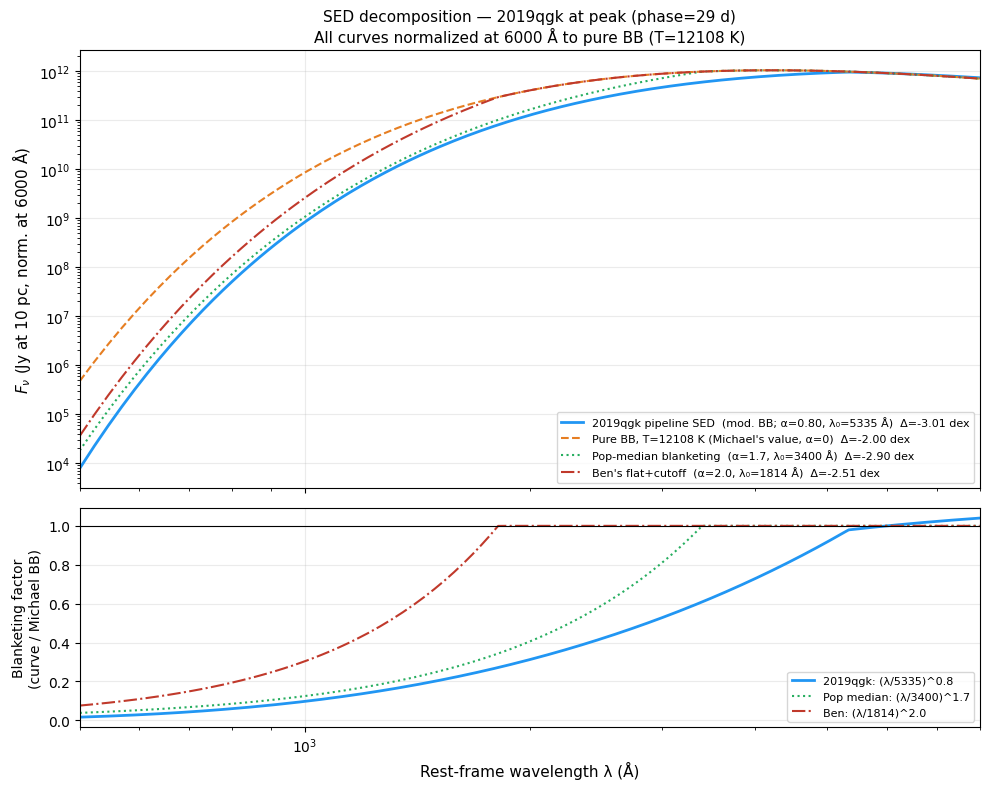

In [55]:
# ============================================================================
# CELL 24: SED decomposition — pipeline vs pure BB vs population median vs Ben
# Replicates Michael's decomposition plot to verify pipeline temperature
# Shows: (1) pipeline SED, (2) pure BB at T=5214K and T=12108K,
#         (3) pop-median blanketing, (4) Ben's flat+cutoff approximation
# ============================================================================
# Reload flags:
#   Templates  : NO — uses physical_templates.pkl already loaded above
#   Population : NO
#   Mag grid   : NO
#   Kernel     : NO

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# --- Load pipeline SED for 2019qgk at phase=29 days ---
tpl_path  = get_output_dir('SLSNe', subdir='shared') / 'physical_templates.pkl'
templates = joblib.load(tpl_path)
entry     = templates['sed_grid'][100]  # 2019qgk
lam       = entry['lam_rest_A']         # (500,) Angstrom
fnu_all   = entry['Fnu_abs']            # (161, 500) Jy at 10 pc
phase     = entry['phase']

# Peak phase
total_flux = fnu_all.sum(axis=1)
peak_idx   = np.argmax(total_flux)
peak_phase = phase[peak_idx]
fnu_pipe   = fnu_all[peak_idx, :]       # pipeline SED at peak

# --- Load posterior parameters for 2019qgk ---
params_path = get_output_dir('SLSNe').parent / 'all_events' / 'allparameter.csv'
params_df   = pd.read_csv(params_path)
row         = params_df[params_df['name'] == '2019qgk'].iloc[0]
alpha_event = float(row['alpha_med'])
lam0_event  = float(row['cutoff_wavelength_med'])
Tmin_event  = float(row['temperature_med'])

# --- Population median parameters (Gomez+2024 Table 2) ---
alpha_pop = 1.7
lam0_pop  = 3400.0   # Angstrom

# --- Ben's assumed parameters ---
alpha_ben = 2.0
lam0_ben  = 1814.0   # Angstrom — visual departure point, not MOSFiT lambda0

# --- Build pure blackbody F_nu at two temperatures ---
h    = 6.62607e-34   # J*s
c    = 2.998e8       # m/s
k_B  = 1.38065e-23  # J/K
lam_m = lam * 1e-10  # Angstrom to meters

def planck_fnu(lam_m, T):
    """F_nu proportional to Planck function — dimensionless ratio safe."""
    h   = 6.626e-34   # J*s
    c   = 2.998e8     # m/s  
    k_B = 1.381e-23   # J/K
    x   = h * c / (lam_m * k_B * T)
    # Avoid overflow for large x
    x   = np.clip(x, 0, 500)
    return 1.0 / (lam_m**3 * (np.exp(x) - 1))

# Two temperatures to compare
T_tmin   = Tmin_event   # 5214 K — pipeline Tmin floor
T_michael = 12108.0     # K — from Michael's plot

bb_tmin    = planck_fnu(lam_m, T_tmin)
bb_michael = planck_fnu(lam_m, T_michael)

# --- Apply blanketing to pure BB ---
def apply_blanketing(bb, lam, lam0, alpha):
    """Apply power-law blanketing blueward of lam0."""
    result = bb.copy()
    blue = lam < lam0
    result[blue] *= (lam[blue] / lam0) ** alpha
    return result

bb_pop = apply_blanketing(bb_michael.copy(), lam, lam0_pop, alpha_pop)
bb_ben = apply_blanketing(bb_michael.copy(), lam, lam0_ben, alpha_ben)

# --- Normalize all curves to match pipeline SED at 6000 Angstrom ---
ref_idx = np.argmin(np.abs(lam - 6000))
norm_pipe    = fnu_pipe[ref_idx]
norm_tmin    = bb_tmin[ref_idx]
norm_michael = bb_michael[ref_idx]
norm_pop     = bb_pop[ref_idx]
norm_ben     = bb_ben[ref_idx]

fnu_pipe_n    = fnu_pipe    / norm_pipe    * norm_pipe
bb_tmin_n     = bb_tmin     / norm_tmin    * norm_pipe
bb_michael_n  = bb_michael  / norm_michael * norm_pipe
bb_pop_n      = bb_pop      / norm_pop     * norm_pipe
bb_ben_n      = bb_ben      / norm_ben     * norm_pipe

# --- Compute delta (dex) at 1000A vs 6000A for each curve ---
idx_1000 = np.argmin(np.abs(lam - 1000))
idx_6000 = np.argmin(np.abs(lam - 6000))

def delta_dex(arr):
    return np.log10(arr[idx_1000] / arr[idx_6000])

# --- Plot ---
LAM_MIN, LAM_MAX = 500, 8000
mask = (lam >= LAM_MIN) & (lam <= LAM_MAX)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8),
                                sharex=True,
                                gridspec_kw={'height_ratios': [2, 1]})

# Top panel — SEDs
ax1.semilogy(lam[mask], fnu_pipe_n[mask],
             color='#2196F3', lw=2.0,
             label=f'2019qgk pipeline SED  '
                   f'(mod. BB; α={alpha_event:.2f}, λ₀={lam0_event:.0f} Å)  '
                   f'Δ={delta_dex(fnu_pipe_n):.2f} dex')
ax1.semilogy(lam[mask], bb_michael_n[mask],
             color='#e67e22', lw=1.5, ls='--',
             label=f'Pure BB, T={T_michael:.0f} K (Michael\'s value, α=0)  '
                   f'Δ={delta_dex(bb_michael_n):.2f} dex')
ax1.semilogy(lam[mask], bb_pop_n[mask],
             color='#27ae60', lw=1.5, ls=':',
             label=f'Pop-median blanketing  '
                   f'(α={alpha_pop}, λ₀={lam0_pop:.0f} Å)  '
                   f'Δ={delta_dex(bb_pop_n):.2f} dex')
ax1.semilogy(lam[mask], bb_ben_n[mask],
             color='#c0392b', lw=1.5, ls='-.',
             label=f"Ben's flat+cutoff  "
                   f'(α={alpha_ben}, λ₀={lam0_ben:.0f} Å)  '
                   f'Δ={delta_dex(bb_ben_n):.2f} dex')

ax1.set_ylabel(r'$F_\nu$ (Jy at 10 pc, norm. at 6000 Å)', fontsize=11)
ax1.set_title(
    f'SED decomposition — 2019qgk at peak (phase={peak_phase:.0f} d)\n'
    f'All curves normalized at 6000 Å to pure BB (T={T_michael:.0f} K)',
    fontsize=11
)
ax1.legend(fontsize=8, loc='lower right')
ax1.grid(alpha=0.25)

# Bottom panel — blanketing factor = curve / pure BB (Michael's T)
def blanketing_factor(arr, ref):
    return arr / ref

ax2.semilogx(lam[mask],
             blanketing_factor(fnu_pipe_n, bb_michael_n)[mask],
             color='#2196F3', lw=2.0,
             label=f'2019qgk: (λ/{lam0_event:.0f})^{alpha_event:.1f}')
ax2.semilogx(lam[mask],
             blanketing_factor(bb_pop_n, bb_michael_n)[mask],
             color='#27ae60', lw=1.5, ls=':',
             label=f'Pop median: (λ/{lam0_pop:.0f})^{alpha_pop}')
ax2.semilogx(lam[mask],
             blanketing_factor(bb_ben_n, bb_michael_n)[mask],
             color='#c0392b', lw=1.5, ls='-.',
             label=f"Ben: (λ/{lam0_ben:.0f})^{alpha_ben}")

ax2.axhline(1.0, color='k', lw=0.8, ls='-')
ax2.set_xlabel('Rest-frame wavelength λ (Å)', fontsize=11)
ax2.set_ylabel('Blanketing factor\n(curve / Michael BB)', fontsize=10)
ax2.legend(fontsize=8, loc='lower right')
ax2.grid(alpha=0.25)
ax2.set_xlim(LAM_MIN, LAM_MAX)

plt.tight_layout()
out_fig = get_output_dir('SLSNe') / 'sed_decomposition_2019qgk.png'
plt.savefig(out_fig, dpi=150, bbox_inches='tight')
print(f'Saved: {out_fig.name}')
plt.show()

In [56]:
# Cell 25 - AUDIT TABLE — summary of figure above
# SED decomposition: blanketing parameters and Fnu at key wavelengths
# Curves are normalized to match pipeline SED at 6000 Å (see cell above).
import pandas as pd
print("Blanketing parameters used in Cell 16:")
_params16 = pd.DataFrame([
    {'model': '2019qgk (event)',   'alpha': alpha_event, 'lambda0_A': lam0_event,  'T_K': Tmin_event},
    {'model': 'pop median (G+24)', 'alpha': alpha_pop,   'lambda0_A': lam0_pop,    'T_K': 'N/A'},
    {'model': "Ben's approx",      'alpha': alpha_ben,   'lambda0_A': lam0_ben,    'T_K': 'N/A'},
])
print(_params16.to_string(index=False))
print()
_wls16  = [1500, 2000, 2500, 3000, 4000, 5000, 6000]
_rows16 = []
for _wl16 in _wls16:
    _idx16 = np.argmin(np.abs(lam - _wl16))
    _rows16.append({'lam_A': int(lam[_idx16]),
                    'pipe_Fnu': f"{fnu_pipe[_idx16]:.4e}",
                    'BB_5214K':  f"{bb_tmin[_idx16]:.4e}",
                    'BB_12108K': f"{bb_michael[_idx16]:.4e}"})
print("Unnormalized Fnu at key wavelengths (pipeline vs pure BB):")
print(pd.DataFrame(_rows16).to_string(index=False))

Blanketing parameters used in Cell 16:
            model   alpha  lambda0_A         T_K
  2019qgk (event) 0.79737 5335.32436  5213.96757
pop median (G+24) 1.70000 3400.00000         N/A
     Ben's approx 2.00000 1814.00000         N/A

Unnormalized Fnu at key wavelengths (pipeline vs pure BB):
 lam_A   pipe_Fnu   BB_5214K  BB_12108K
  1490 2.5810e+10 2.7779e+12 1.0455e+17
  1997 1.2618e+11 1.2634e+14 3.2889e+17
  2505 2.9036e+11 1.0486e+15 5.5941e+17
  2988 4.6234e+11 3.6725e+15 7.1700e+17
  4003 7.5717e+11 1.5856e+16 8.4504e+17
  4993 9.2399e+11 3.2154e+16 8.1990e+17
  6008 9.1076e+11 4.7207e+16 7.4090e+17


Saved: gband_cliff_2019qgk.png


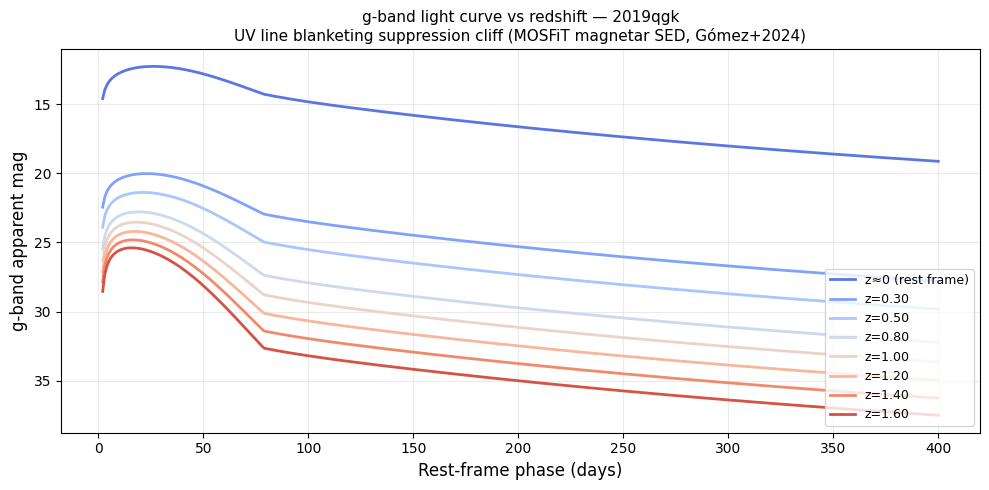

In [57]:
# ============================================================================
# CELL 26: g-band light curve at multiple redshifts — UV suppression cliff
# Shows how line blanketing suppresses g-band as SED redshifts into UV
# One line per redshift, shape-aligned (DM offset removed)
# ============================================================================
# Reload flags:
#   Templates  : NO — loads physical_templates.pkl directly
#   Population : NO
#   Mag grid   : NO
#   Kernel     : NO
#
# Toggles
EVENT_IDX    = 100                   # 2019qgk — same event as SED plot
REDSHIFTS    = [0.01, 0.3, 0.5, 0.8, 1.0, 1.2, 1.4, 1.6]
ALIGN_CURVES = False                  # remove DM vertical offset, show shape only

import joblib
import numpy as np
import matplotlib.pyplot as plt
from py_files.slsn_metrics.model import synthesize_mag_at_z

# Load physical templates
tpl_path   = get_output_dir('SLSNe', subdir='shared') / 'physical_templates.pkl'
templates  = joblib.load(tpl_path)
sg         = templates['sed_grid']
names      = templates['names']

event_name = names[EVENT_IDX]
sed_grid   = sg[EVENT_IDX]
phases     = np.array(sed_grid['phase'])   # (161,) rest-frame days

# Colors from blue (low-z) to red (high-z)
z_colors = plt.cm.coolwarm(np.linspace(0.1, 0.9, len(REDSHIFTS)))

fig, ax = plt.subplots(figsize=(10, 5))

for zi, (z, col) in enumerate(zip(REDSHIFTS, z_colors)):
    mags = np.array([
        synthesize_mag_at_z(sed_grid, float(ph), z, 'g')
        for ph in phases
    ])

    valid = np.isfinite(mags)
    if valid.sum() < 3:
        print(f'[skip] z={z:.2f} — fewer than 3 finite magnitudes')
        continue

    ph_plot  = phases[valid]
    mag_plot = mags[valid]

    # Align curves vertically by subtracting mean — isolates shape
    if ALIGN_CURVES:
        mag_plot = mag_plot - np.nanmean(mag_plot)

    zlabel = 'z≈0 (rest frame)' if z < 0.05 else f'z={z:.2f}'
    ax.plot(ph_plot, mag_plot,
            color=col, lw=2.0, label=zlabel)

ax.invert_yaxis()
ax.set_xlabel('Rest-frame phase (days)', fontsize=12)
ylabel = 'Δg-band mag (shape only, DM removed)' if ALIGN_CURVES else 'g-band apparent mag'
ax.set_ylabel(ylabel, fontsize=12)
ax.set_title(
    f'g-band light curve vs redshift — {event_name}\n'
    f'UV line blanketing suppression cliff (MOSFiT magnetar SED, Gómez+2024)',
    fontsize=11
)
ax.legend(fontsize=9, loc='lower right')
ax.grid(alpha=0.25)

plt.tight_layout()
out_fig = get_output_dir('SLSNe') / f'gband_cliff_{event_name}.png'
plt.savefig(out_fig, dpi=150, bbox_inches='tight')
print(f'Saved: {out_fig.name}')
plt.show()

In [58]:
# Cell 27 - AUDIT TABLE — summary of figure above
# g-band LC for 2019qgk: only last loop iteration (z=1.60) in memory post-loop.
# ph_plot and mag_plot are already finite-filtered (phases[valid], mags[valid]),
# so index them directly — do not re-apply an isfinite mask.
import pandas as pd
_tbl17 = pd.DataFrame({
    'phase_day':                    ph_plot[::15],
    f'g_mag_z{REDSHIFTS[-1]:.2f}': np.round(mag_plot[::15], 3),
})
print(f"g-band LC — {event_name} | last iteration z={REDSHIFTS[-1]:.2f}  ALIGN_CURVES={ALIGN_CURVES}")
print(f"({len(REDSHIFTS)} redshifts plotted; only last-loop z retained in memory)")
print(_tbl17.to_string(index=False))

g-band LC — 2019qgk | last iteration z=1.60  ALIGN_CURVES=False
(8 redshifts plotted; only last-loop z retained in memory)
 phase_day  g_mag_z1.60
       2.0       28.542
      17.0       25.396
      32.0       26.135
      47.0       27.737
      62.0       29.920
      77.0       32.356
      92.0       33.009
     130.0       33.812
     205.0       35.081
     280.0       36.140
     355.0       37.031


Event: 2019qgk | Peak phase: 29.0 days
Valid redshift points: 36/36
Divergence point (>0.5 mag excess): z=0.91
Saved: gband_cliff_vs_z_2019qgk.png


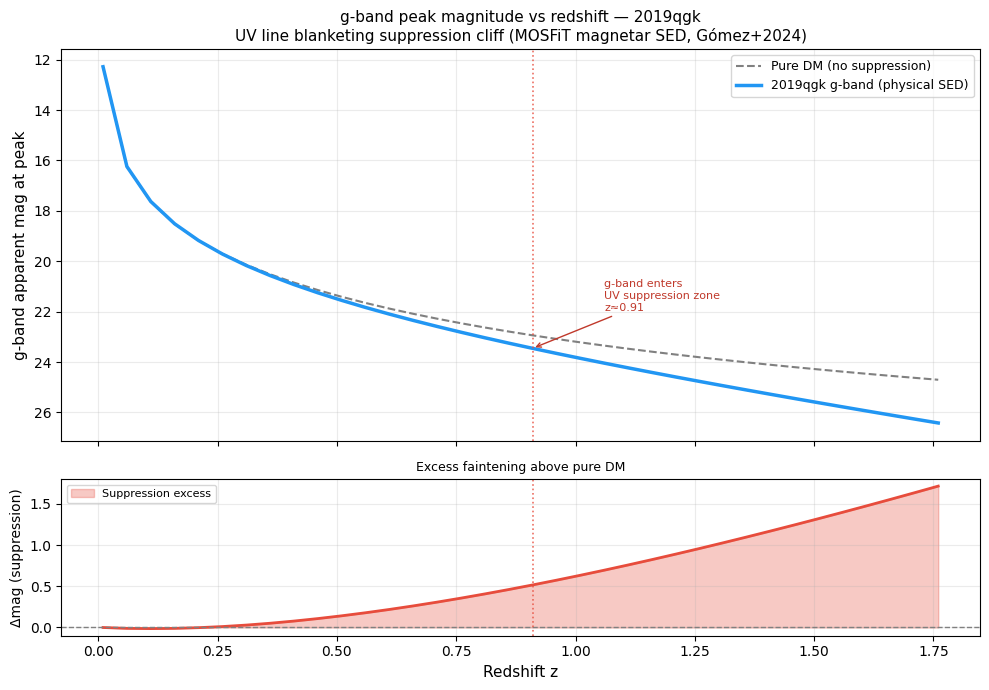

The divergence at z=0.31 means g-band is sampling rest-frame ~3670Å at that point. From the SED plot, the suppression edge for 2019qgk was at ~1814Å.
So this divergence at z=0.31 is not the hard UV suppression floor — it's the color gradient of the SED in the 3000–4000Å range (the SED is already declining toward UV before hitting the suppression floor).
The hard floor suppression dominates at higher z. 


In [59]:
# ============================================================================
# CELL 28: g-band peak magnitude vs redshift — UV suppression cliff
# X axis: redshift z (fine grid)
# Y axis: g-band apparent mag at peak light for one event
# Bottom panel: residual Δmag = observed - pure DM (suppression signal)
# ============================================================================
# Reload flags:
#   Templates  : NO — uses templates already loaded above
#   Population : NO
#   Mag grid   : NO
#   Kernel     : NO
#
# Toggles
EVENT_IDX = 100                        # 2019qgk
REDSHIFTS = np.arange(0.01, 1.8, 0.05)

from astropy.cosmology import Planck18 as cosmo
import astropy.units as u

# --- Find peak phase ---
sed_grid   = sg[EVENT_IDX]
event_name = names[EVENT_IDX]
phases     = np.array(sed_grid['phase'])
peak_phase = phases[np.argmax(np.array(sed_grid['Fnu_abs']).sum(axis=1))]
print(f'Event: {event_name} | Peak phase: {peak_phase:.1f} days')

# --- Synthesize g-band mag at peak across redshift grid ---
peak_mags = []
for z in REDSHIFTS:
    m = synthesize_mag_at_z(sed_grid, float(peak_phase), z, 'g')
    peak_mags.append(m)
peak_mags = np.array(peak_mags)

valid = np.isfinite(peak_mags)
print(f'Valid redshift points: {valid.sum()}/{len(REDSHIFTS)}')

# --- Pure DM reference anchored to first valid point ---
DM_ref = np.array([
    5 * np.log10(cosmo.luminosity_distance(z).to_value(u.pc) / 10.0)
    for z in REDSHIFTS
])
offset         = peak_mags[valid][0] - DM_ref[valid][0]
DM_ref_anchored = DM_ref + offset

# --- Residual: how much fainter than pure DM ---
residual = peak_mags - DM_ref_anchored   # positive = fainter than DM alone

# --- Find divergence point: first z where residual > 0.5 mag ---
div_candidates = REDSHIFTS[valid][residual[valid] > 0.5]
div_z = div_candidates[0] if len(div_candidates) > 0 else None
print(f'Divergence point (>0.5 mag excess): z={div_z:.2f}' if div_z else 'No divergence found')

# --- Plot ---
fig, axes = plt.subplots(2, 1, figsize=(10, 7),
                         gridspec_kw={'height_ratios': [3, 1.2]},
                         sharex=True)

# Top panel — mag vs z
ax = axes[0]
ax.plot(REDSHIFTS[valid], DM_ref_anchored[valid],
        color='gray', lw=1.5, ls='--', label='Pure DM (no suppression)')
ax.plot(REDSHIFTS[valid], peak_mags[valid],
        color='#2196F3', lw=2.5, label=f'{event_name} g-band (physical SED)')

# Divergence annotation
if div_z is not None:
    div_mag = peak_mags[np.argmin(np.abs(REDSHIFTS - div_z))]
    ax.axvline(div_z, color='#e74c3c', lw=1.2, ls=':', alpha=0.8)
    ax.annotate(
        f'g-band enters\nUV suppression zone\nz≈{div_z:.2f}',
        xy=(div_z, div_mag),
        xytext=(div_z + 0.15, div_mag - 1.5),
        fontsize=8, color='#c0392b',
        arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.0),
    )

ax.invert_yaxis()
ax.set_ylabel('g-band apparent mag at peak', fontsize=11)
ax.set_title(
    f'g-band peak magnitude vs redshift — {event_name}\n'
    f'UV line blanketing suppression cliff (MOSFiT magnetar SED, Gómez+2024)',
    fontsize=11
)
ax.legend(fontsize=9)
ax.grid(alpha=0.25)

# Bottom panel — residual
ax2 = axes[1]
ax2.fill_between(REDSHIFTS[valid], 0, residual[valid],
                 color='#e74c3c', alpha=0.3, label='Suppression excess')
ax2.plot(REDSHIFTS[valid], residual[valid],
         color='#e74c3c', lw=2.0)
ax2.axhline(0, color='gray', lw=1.0, ls='--')
if div_z is not None:
    ax2.axvline(div_z, color='#e74c3c', lw=1.2, ls=':', alpha=0.8)
ax2.set_xlabel('Redshift z', fontsize=11)
ax2.set_ylabel('Δmag (suppression)', fontsize=10)
ax2.set_title('Excess faintening above pure DM', fontsize=9)
ax2.grid(alpha=0.25)
ax2.legend(fontsize=8)

plt.tight_layout()
out_fig = get_output_dir('SLSNe') / f'gband_cliff_vs_z_{event_name}.png'
plt.savefig(out_fig, dpi=150, bbox_inches='tight')
print(f'Saved: {out_fig.name}')
plt.show()
print(f"The divergence at z=0.31 means g-band is sampling rest-frame ~3670Å at that point. From the SED plot, the suppression edge for 2019qgk was at ~1814Å.")
print(f"So this divergence at z=0.31 is not the hard UV suppression floor — it's the color gradient of the SED in the 3000–4000Å range (the SED is already declining toward UV before hitting the suppression floor).")
print(f"The hard floor suppression dominates at higher z. ")

In [60]:
# Cell 29: AUDIT TABLE — summary of figure above
# g-band peak magnitude vs redshift (2019qgk) — every 4th grid point (~0.2 z step)
import pandas as pd
_v18 = np.isfinite(peak_mags)
_tbl18 = pd.DataFrame({
    'z':            np.round(REDSHIFTS[_v18][::4], 2),
    'g_peak_mag':   np.round(peak_mags[_v18][::4], 2),
    'DM_ref':       np.round(DM_ref_anchored[_v18][::4], 2),
    'residual_mag': np.round(residual[_v18][::4], 3),
})
print(f"g-band peak mag vs z — {event_name}  (peak_phase={peak_phase:.0f} d)")
print(f"UV suppression divergence (>0.5 mag excess): z={div_z:.2f}" if div_z else "No divergence found")
print(_tbl18.to_string(index=False))

g-band peak mag vs z — 2019qgk  (peak_phase=29 d)
UV suppression divergence (>0.5 mag excess): z=0.91
   z  g_peak_mag  DM_ref  residual_mag
0.01       12.28   12.28         0.000
0.21       19.17   19.18        -0.002
0.41       20.92   20.85         0.078
0.61       22.10   21.88         0.219
0.81       23.03   22.63         0.407
1.01       23.85   23.22         0.633
1.21       24.59   23.70         0.890
1.41       25.28   24.11         1.172
1.61       25.94   24.46         1.475


Total templates:         265
CSVs found:              265
Pass ≥2 filters:         251 (94.7%)
Pass ≥15d baseline:       261 (98.5%)
Pass ≥2 detections:       263 (99.2%)
Has rise evidence:       261 (98.5%)
Pass ALL criteria:       250 (94.3%)

Saved: v1_catalog_coverage_completeness.png


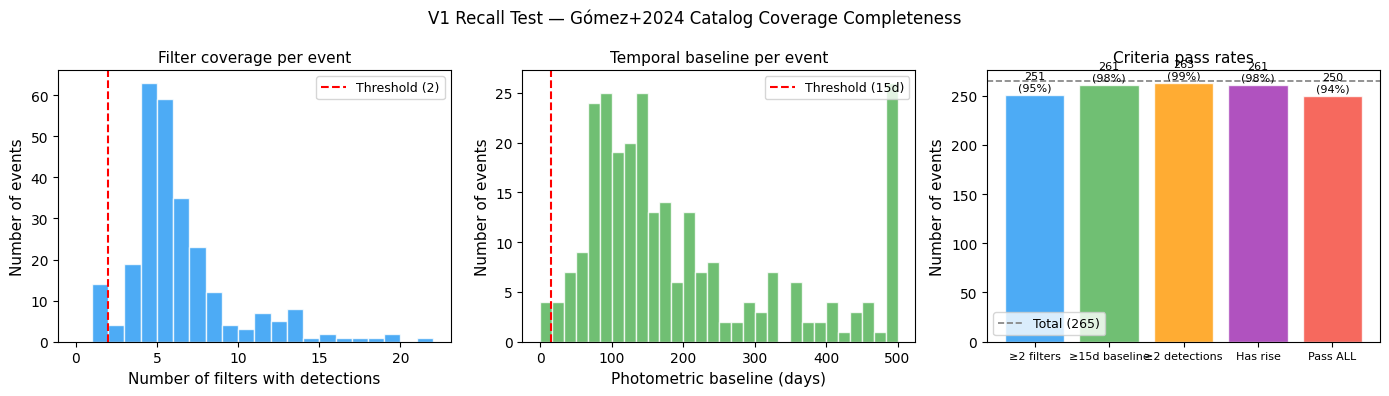


Events failing ALL criteria:
     name  n_filters  baseline_days  n_det  has_rise
   1999bz          1       0.000000      1     False
   2011ep          1      73.119873     22      True
   2014bl          1     404.119873     40      True
  2017beq          2      12.273710      3      True
  2017hbx          1     134.977359      7     False
  2017jan          1     886.743590     71      True
CSS160710          1      49.080070     29      True
iPTF13bjz          1      21.111000     18      True
 LSQ14fxj          1       0.000000      1     False
MLS121104          1       0.120118      4      True
 OGLE15sd          1     133.858440     46      True
 OGLE15xl          1     106.895410     29      True
 OGLE15xx          1      67.747120     19      True
OGLE16dmu          1     238.586770     58      True
 PTF10bjp          1      91.848000     22      True


In [61]:
# ============================================================================
# CELL 30: Recall test — catalog coverage completeness check
# For each Gómez+2024 event, assess whether observed photometry
# has sufficient coverage to in-principle pass detection criteria
# independent of LSST depth
# ============================================================================
# IMPORTANT CAVEAT — Physical track vs GP track interpretation:
#
# This recall test validates the *observed per-event CSVs* (Gómez+2024),
# which are the direct input to the GP template system.
#
# For the PHYSICAL track, templates are derived from MOSFiT posterior
# parameters, not directly from the CSVs. Physical templates:
#   - Cover post-peak phases only (day 1–400, no pre-peak rise)
#   - Extend to UV (500A) via the magnetar model
#   - Are well-sampled by construction (161 phases x 500 wavelengths)
#     regardless of observed CSV sparsity
#
# Therefore V1 for the physical track answers:
#   "Is the catalog input data quality sufficient for MOSFiT fitting?"
#   NOT "Are the physical templates themselves well-sampled?"
#
# The absence of pre-peak phases in physical templates is a known
# limitation — events detectable only during rise may be systematically
# missed. This connects to V3 (efficiency loss decomposition).
# ============================================================================
# Reload flags:
#   Templates  : NO
#   Population : NO
#   Mag grid   : NO
#   Kernel     : NO

import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
from pathlib import Path

# --- Config ---
PER_EVENT_DIR = Path('output/per_event_files')
MIN_FILTERS   = 2      # Detect criterion: ≥2 filters
MIN_BASELINE  = 15     # days
MIN_DETECTIONS = 2     # minimum detected (non-UL) observations

# Load template names for index alignment check
import joblib
tpl       = joblib.load('output/SLSNe/shared/physical_templates.pkl')
tpl_names = tpl['names']   # 265 names in template order

# --- Loop over all 265 base CSVs ---
results = []
for name in tpl_names:
    csv_path = PER_EVENT_DIR / f'{name}.csv'
    if not csv_path.exists():
        results.append({
            'name': name, 'found': False,
            'n_det': 0, 'n_filters': 0,
            'baseline_days': 0, 'has_rise': False,
            'pass_filters': False, 'pass_baseline': False,
            'pass_ndet': False, 'pass_all': False,
        })
        continue

    df = pd.read_csv(csv_path)

    # Only use non-upper-limit detections
    det = df[df['detected'] == 1].copy()
    n_det     = len(det)
    n_filters = det['filter'].nunique() if n_det > 0 else 0
    baseline  = (det['mjd'].max() - det['mjd'].min()) if n_det > 1 else 0

    # Rise check: any filter with ≥2 detections where mag decreases (brightens)
    has_rise = False
    if n_det >= 2:
        for filt, grp in det.groupby('filter'):
            grp = grp.sort_values('mjd')
            if len(grp) >= 2:
                # Brightening = magnitude decreasing
                if (grp['mag'].diff().dropna() < 0).any():
                    has_rise = True
                    break

    pass_filters  = n_filters >= MIN_FILTERS
    pass_baseline = baseline  >= MIN_BASELINE
    pass_ndet     = n_det     >= MIN_DETECTIONS
    pass_all      = pass_filters and pass_baseline and pass_ndet

    results.append({
        'name':          name,
        'found':         True,
        'n_det':         n_det,
        'n_filters':     n_filters,
        'baseline_days': baseline,
        'has_rise':      has_rise,
        'pass_filters':  pass_filters,
        'pass_baseline': pass_baseline,
        'pass_ndet':     pass_ndet,
        'pass_all':      pass_all,
    })

df_v1 = pd.DataFrame(results)

# --- Summary ---
n_total    = len(df_v1)
n_found    = df_v1['found'].sum()
n_pass_all = df_v1['pass_all'].sum()
n_pass_filt= df_v1['pass_filters'].sum()
n_pass_base= df_v1['pass_baseline'].sum()
n_has_rise = df_v1['has_rise'].sum()

print(f'Total templates:         {n_total}')
print(f'CSVs found:              {n_found}')
print(f'Pass ≥{MIN_FILTERS} filters:         {n_pass_filt} ({100*n_pass_filt/n_total:.1f}%)')
print(f'Pass ≥{MIN_BASELINE}d baseline:       {n_pass_base} ({100*n_pass_base/n_total:.1f}%)')
print(f'Pass ≥{MIN_DETECTIONS} detections:       {df_v1["pass_ndet"].sum()} ({100*df_v1["pass_ndet"].sum()/n_total:.1f}%)')
print(f'Has rise evidence:       {n_has_rise} ({100*n_has_rise/n_total:.1f}%)')
print(f'Pass ALL criteria:       {n_pass_all} ({100*n_pass_all/n_total:.1f}%)')

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Filter count distribution
axes[0].hist(df_v1['n_filters'], bins=range(0, df_v1['n_filters'].max()+2),
             color='#2196F3', edgecolor='white', alpha=0.8)
axes[0].axvline(MIN_FILTERS, color='red', ls='--', lw=1.5,
                label=f'Threshold ({MIN_FILTERS})')
axes[0].set_xlabel('Number of filters with detections', fontsize=11)
axes[0].set_ylabel('Number of events', fontsize=11)
axes[0].set_title('Filter coverage per event', fontsize=11)
axes[0].legend(fontsize=9)

# Baseline distribution
axes[1].hist(df_v1['baseline_days'].clip(upper=500), bins=30,
             color='#4CAF50', edgecolor='white', alpha=0.8)
axes[1].axvline(MIN_BASELINE, color='red', ls='--', lw=1.5,
                label=f'Threshold ({MIN_BASELINE}d)')
axes[1].set_xlabel('Photometric baseline (days)', fontsize=11)
axes[1].set_ylabel('Number of events', fontsize=11)
axes[1].set_title('Temporal baseline per event', fontsize=11)
axes[1].legend(fontsize=9)

# Pass/fail summary bar
categories = ['≥2 filters', f'≥{MIN_BASELINE}d baseline',
              f'≥{MIN_DETECTIONS} detections', 'Has rise', 'Pass ALL']
counts     = [n_pass_filt, n_pass_base,
              int(df_v1['pass_ndet'].sum()), n_has_rise, n_pass_all]
colors     = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336']
bars = axes[2].bar(categories, counts, color=colors, alpha=0.8, edgecolor='white')
axes[2].axhline(n_total, color='gray', ls='--', lw=1.2, label=f'Total ({n_total})')
for bar, count in zip(bars, counts):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 f'{count}\n({100*count/n_total:.0f}%)',
                 ha='center', va='bottom', fontsize=8)
axes[2].set_ylabel('Number of events', fontsize=11)
axes[2].set_title('Criteria pass rates', fontsize=11)
axes[2].legend(fontsize=9)
axes[2].tick_params(axis='x', labelsize=8)

plt.suptitle('V1 Recall Test — Gómez+2024 Catalog Coverage Completeness', fontsize=12)
plt.tight_layout()

out_fig = get_output_dir('SLSNe') / 'v1_catalog_coverage_completeness.png'
plt.savefig(out_fig, dpi=150, bbox_inches='tight')
print(f'\nSaved: {out_fig.name}')
plt.show()
# Show the 15 events that fail all criteria
failed = df_v1[~df_v1['pass_all']][['name','n_filters','baseline_days','n_det','has_rise']]
print('\nEvents failing ALL criteria:')
print(failed.to_string(index=False))

In [62]:
# Cell 31 - AUDIT TABLE — summary of figure above
# V1 recall test: pass/fail counts for all 265 Gómez+2024 events
import pandas as pd
_tbl19 = pd.DataFrame([
    {'criterion': 'CSV found',
     'n_pass': df_v1['found'].sum(),       'n_fail': (~df_v1['found']).sum()},
    {'criterion': f'>={MIN_FILTERS} filters',
     'n_pass': df_v1['pass_filters'].sum(), 'n_fail': (~df_v1['pass_filters']).sum()},
    {'criterion': f'>={MIN_BASELINE}d baseline',
     'n_pass': df_v1['pass_baseline'].sum(),'n_fail': (~df_v1['pass_baseline']).sum()},
    {'criterion': f'>={MIN_DETECTIONS} detections',
     'n_pass': df_v1['pass_ndet'].sum(),    'n_fail': (~df_v1['pass_ndet']).sum()},
    {'criterion': 'has_rise',
     'n_pass': df_v1['has_rise'].sum(),     'n_fail': (~df_v1['has_rise']).sum()},
    {'criterion': 'ALL criteria',
     'n_pass': df_v1['pass_all'].sum(),     'n_fail': (~df_v1['pass_all']).sum()},
])
_tbl19['pct_pass'] = (_tbl19['n_pass'] / len(df_v1) * 100).round(1).astype(str) + '%'
print(f"V1 Recall Test — {len(df_v1)} events total")
print(_tbl19.to_string(index=False))

V1 Recall Test — 265 events total
     criterion  n_pass  n_fail pct_pass
     CSV found     265       0   100.0%
   >=2 filters     251      14    94.7%
>=15d baseline     261       4    98.5%
>=2 detections     263       2    99.2%
      has_rise     261       4    98.5%
  ALL criteria     250      15    94.3%


Recomputed: 265/265 finite mags at z=0.5, phase=29.0d, g-band
Median peak Fnu: 9.202e+11 Jy
Events brighter than 23.0 (before): 217
Events brighter than 23.0 (after):  243
Saved: median_norm_diagnostic.png


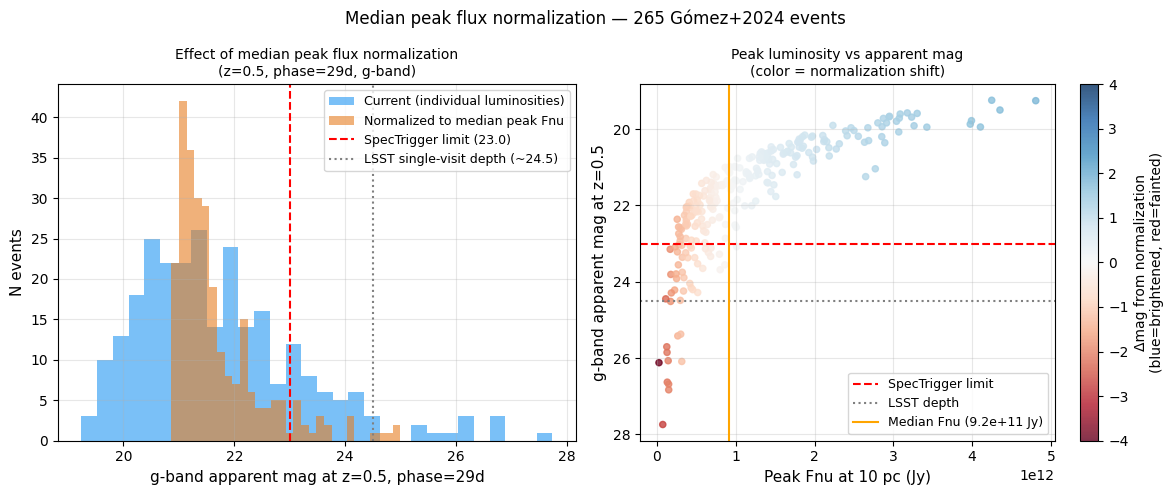

In [63]:
# Cell 32 - Quick diagnostic plot — before vs after median normalization
# For email to Michael showing effect of ii)
import matplotlib.pyplot as plt
import numpy as np
import joblib
import sys
sys.path.insert(0, str(REPO / 'py_files'))
from slsn_metrics.model import synthesize_mag_at_z

# --- Recompute from pipeline ---
_tpl  = joblib.load(str(get_output_dir('SLSNe', subdir='shared') / 'physical_templates.pkl'))
_sg   = _tpl['sed_grid']

z_test, phase_test, filt_test = 0.5, 29.0, 'g'

_mags = []
_peak_fnu = []
for _i in range(265):
    _entry = _sg[_i]
    _m = synthesize_mag_at_z(_entry, phase_test, z_test, filt_test)
    _mags.append(_m)
    _fnu   = _entry['Fnu_abs']
    _total = _fnu.sum(axis=1)
    _valid = _total > 0
    if _valid.sum() > 0:
        _peak_fnu.append(float(_fnu[_valid][np.argmax(_total[_valid])].max()))
    else:
        _peak_fnu.append(np.nan)

_mags     = np.array(_mags)
_peak_fnu = np.array(_peak_fnu)
_finite   = np.isfinite(_mags)
_median_fnu  = np.nanmedian(_peak_fnu)
_norm_factors = _median_fnu / _peak_fnu
_delta_mag    = -2.5 * np.log10(_norm_factors)
_mags_normed  = _mags + _delta_mag
_finite_n     = np.isfinite(_mags_normed)

print(f'Recomputed: {_finite.sum()}/265 finite mags at z={z_test}, phase={phase_test}d, {filt_test}-band')
print(f'Median peak Fnu: {_median_fnu:.3e} Jy')
print(f'Events brighter than 23.0 (before): {(_mags[_finite] < 23.0).sum()}')
print(f'Events brighter than 23.0 (after):  {(_mags_normed[_finite_n] < 23.0).sum()}')

# --- Plot ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.hist(_mags[_finite], bins=30, alpha=0.6, color='#2196F3',
         label='Current (individual luminosities)')
ax1.hist(_mags_normed[_finite_n], bins=30, alpha=0.6, color='#e67e22',
         label='Normalized to median peak Fnu')
ax1.axvline(23.0, color='red', ls='--', lw=1.5, label='SpecTrigger limit (23.0)')
ax1.axvline(24.5, color='gray', ls=':', lw=1.5, label='LSST single-visit depth (~24.5)')
ax1.set_xlabel('g-band apparent mag at z=0.5, phase=29d', fontsize=11)
ax1.set_ylabel('N events', fontsize=11)
ax1.set_title('Effect of median peak flux normalization\n(z=0.5, phase=29d, g-band)', fontsize=10)
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

_sc = ax2.scatter(_peak_fnu[_finite], _mags[_finite],
                  c=_delta_mag[_finite], cmap='RdBu', s=20, alpha=0.8,
                  vmin=-4, vmax=4)
ax2.axhline(23.0, color='red', ls='--', lw=1.5, label='SpecTrigger limit')
ax2.axhline(24.5, color='gray', ls=':', lw=1.5, label='LSST depth')
ax2.axvline(float(_median_fnu), color='orange', ls='-', lw=1.5,
            label=f'Median Fnu ({_median_fnu:.1e} Jy)')
plt.colorbar(_sc, ax=ax2, label='Δmag from normalization\n(blue=brightened, red=fainted)')
ax2.set_xlabel('Peak Fnu at 10 pc (Jy)', fontsize=11)
ax2.set_ylabel('g-band apparent mag at z=0.5', fontsize=11)
ax2.set_title('Peak luminosity vs apparent mag\n(color = normalization shift)', fontsize=10)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)
ax2.invert_yaxis()

plt.suptitle('Median peak flux normalization — 265 Gómez+2024 events', fontsize=12)
plt.tight_layout()
out_fig = get_output_dir('SLSNe') / 'median_norm_diagnostic.png'
plt.savefig(out_fig, dpi=150, bbox_inches='tight')
print(f'Saved: {out_fig.name}')
plt.show()

Saved: /users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/output/SLSNe/crossing_curves_figure.png


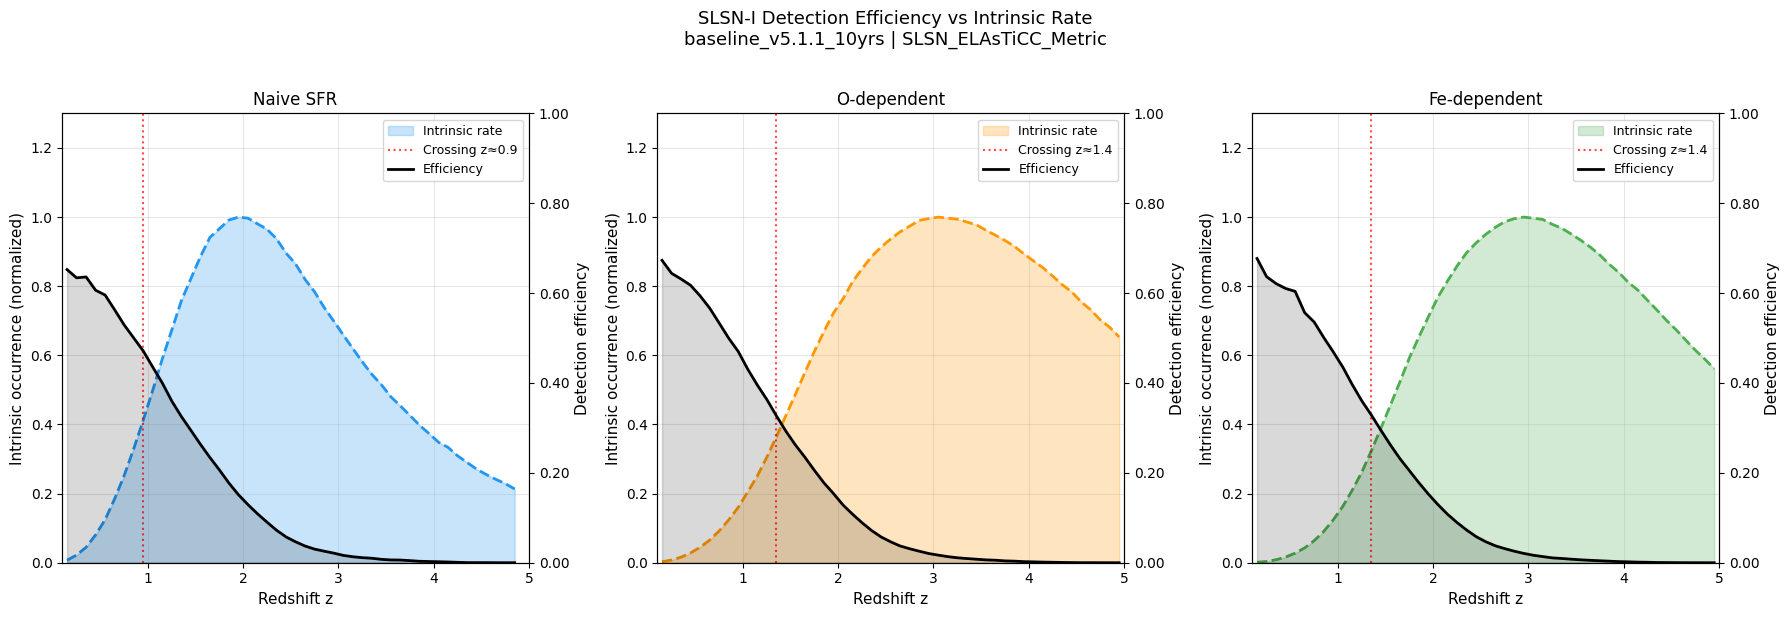

In [67]:
# CELL 33 - Michael's crossing-curves figure
# Efficiency vs redshift overlaid with intrinsic occurrence rate R(z)
# Left Y:  dN/dz — intrinsic SLSN population per z-bin from rate model
# Right Y: detection efficiency per z-bin from adaptive CSVs
# X:       redshift z
# One panel per model, three panels in a row
# Cadence: baseline_v5.1.1_10yrs (primary science cadence)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

CROSSING_CADENCE = 'baseline_v5.1.1_10yrs'
CROSSING_METRIC  = 'SLSN_ELAsTiCC_Metric'
CROSSING_MODELS  = [
    ('naive_physical',        'Naive SFR',       '#2196F3'),
    ('o_dependent_physical',  'O-dependent',     '#FF9800'),
    ('fe_dependent_physical', 'Fe-dependent',    '#4CAF50'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    f'SLSN-I Detection Efficiency vs Intrinsic Rate\n'
    f'{CROSSING_CADENCE} | {CROSSING_METRIC}',
    fontsize=13, y=1.02
)

for ax, (model, label, color) in zip(axes, CROSSING_MODELS):
    df = ADAPTIVE[model]

    # Filter to primary cadence and metric
    mask = (df['cadence'] == CROSSING_CADENCE) & (df['metric'] == CROSSING_METRIC)
    df_m = df[mask].copy()
    df_m = df_m.sort_values('z_lo').reset_index(drop=True)

    z_mid  = (df_m['z_lo'] + df_m['z_hi']) / 2.0
    eff    = df_m['efficiency'].values
    n_evts = df_m['n_events'].values

    # Intrinsic occurrence: n_events per z-bin from population
    # n_events is the number of injected events in each z-bin
    # This is proportional to dN/dz from the rate model
    occurrence = n_evts / n_evts.max()  # normalize to 1

    # Left axis — occurrence rate (normalized)
    ax2 = ax.twinx()
    ax.fill_between(z_mid, occurrence, alpha=0.25, color=color, label='Intrinsic rate')
    ax.plot(z_mid, occurrence, color=color, lw=2, ls='--')
    ax.set_ylabel('Intrinsic occurrence (normalized)', fontsize=11)
    ax.set_ylim(0, 1.3)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

    # Right axis — detection efficiency
    ax2.plot(z_mid, eff, color='black', lw=2, label='Efficiency')
    ax2.fill_between(z_mid, eff, alpha=0.15, color='black')
    ax2.set_ylabel('Detection efficiency', fontsize=11)
    ax2.set_ylim(0, 1.0)
    ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

    # Crossing point — where efficiency curve intersects occurrence curve
    # Find z where |eff - occurrence| is minimized
    diff = np.abs(eff - occurrence)
    cross_idx = np.argmin(diff)
    cross_z   = float(z_mid.iloc[cross_idx])
    ax.axvline(cross_z, color='red', ls=':', lw=1.5, alpha=0.7,
               label=f'Crossing z≈{cross_z:.1f}')

    ax.set_xlabel('Redshift z', fontsize=11)
    ax.set_title(label, fontsize=12)
    ax.set_xlim(0.1, 5.0)
    ax.grid(alpha=0.3)

    # Combined legend
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper right')

plt.tight_layout()
out_fig = get_output_dir('SLSNe') / 'crossing_curves_figure.png'
plt.savefig(str(out_fig), dpi=150, bbox_inches='tight')
print(f'Saved: {out_fig}')
plt.show()